# CFM Volatility Forecasting — Notebook principal

**Auteur** : Adam Kerouredan
**Référence** : G. Paleologo, *The Elements of Quantitative Investing*, Wiley 2024.

Ce notebook orchestre les phases du projet :
- **Phase I** — Ingestion + EDA
- **Phase II** — Feature Engineering + évaluation
- **Phase III** — Neutralisation cross-sectionnelle (préparation à la modélisation)

---

## PHASE I — Ingestion et Analyse Exploratoire

### 1. Chargement des données

In [1]:
import sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import DataLoader

loader = DataLoader(data_dir="../data/")
x_train, y_train, x_test = loader.load_all()

print(f"x_train : {x_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape}")

[WARNING] x_train contient 839634 valeurs manquantes.
[WARNING] x_test contient 875392 valeurs manquantes.
x_train : (636313, 111)
y_train : (636313, 2)
x_test  : (635397, 111)


### 2. EDA — analyse exploratoire complète

DESCRIPTION DU DATASET
  Lignes totales        :    636,313
  Colonnes totales      :        111
  Stocks uniques        :        318
  Jours uniques         :      2,117
  Colonnes volatilité   :         54
  Colonnes return dir.  :         54

VALEURS MANQUANTES
  Lignes avec au moins 1 NaN : 99,701 (15.7%)
  NaN moyen par ligne        : 0.66
  Max NaN sur une ligne      : 53


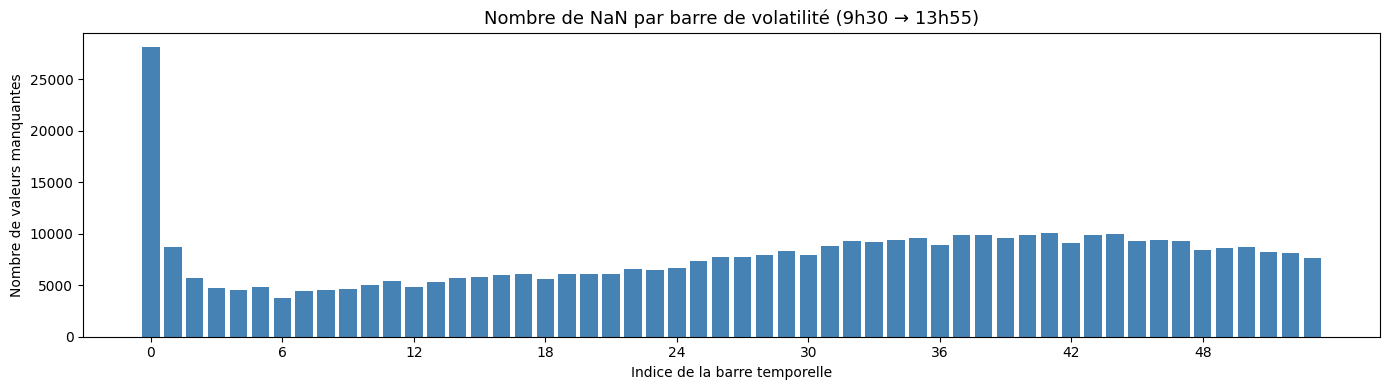


DISTRIBUTION DE LA TARGET (vol 14h-16h)
count    636313.000000
mean          0.183569
std           0.155562
min           0.000132
25%           0.098403
50%           0.141679
75%           0.214632
max           7.581517

  Skewness  : 5.014
  Kurtosis  : 59.902


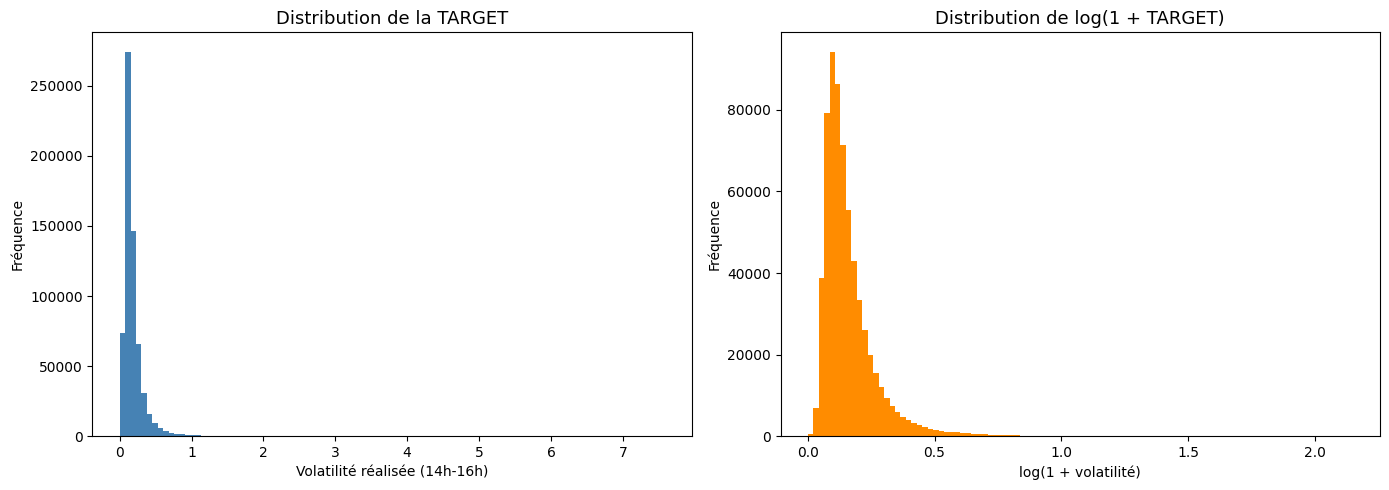


PERSISTANCE DE LA VOLATILITÉ
  Corrélation vol matin / TARGET : 0.8573


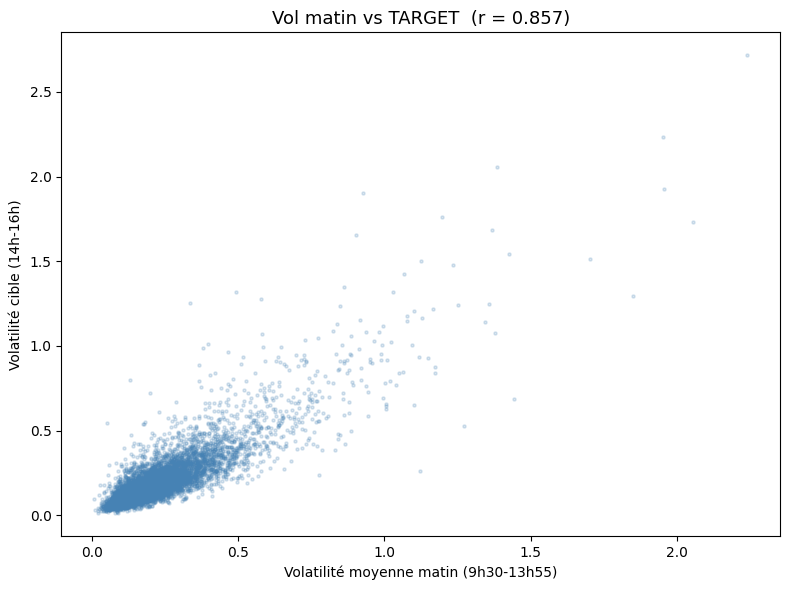

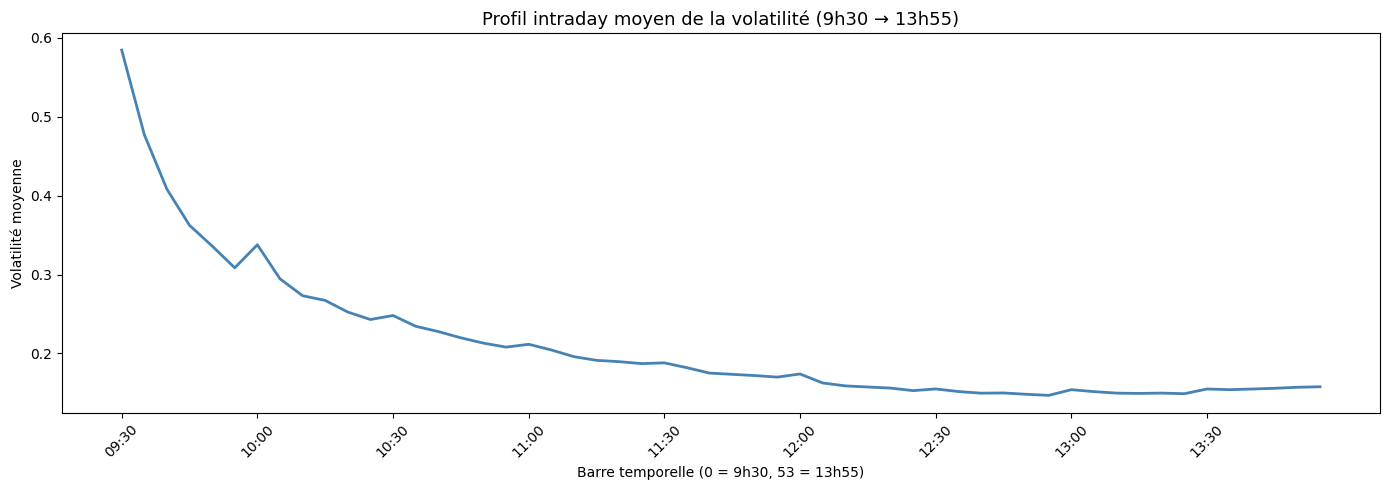

In [2]:
from src.eda_analyzer import EDAAnalyzer

eda = EDAAnalyzer(x_train, y_train, output_dir="../outputs/")
eda.run()

### 3. EDA complémentaire — structure des NaN et profil intraday

In [3]:
# NaN par barre temporelle
missing_per_col = x_train[eda.volatility_columns].isnull().sum()
print("5 premières barres:")
print(missing_per_col.head().to_string())
print("\n5 dernières barres:")
print(missing_per_col.tail().to_string())

# Profil intraday
mean_by_bar = x_train[eda.volatility_columns].mean()
print("\nVol moyenne toutes les 6 barres:")
print(mean_by_bar.iloc[::6].to_string())

5 premières barres:
volatility 09:30:00    28091
volatility 09:35:00     8755
volatility 09:40:00     5657
volatility 09:45:00     4756
volatility 09:50:00     4536

5 dernières barres:
volatility 13:35:00    8606
volatility 13:40:00    8746
volatility 13:45:00    8230
volatility 13:50:00    8166
volatility 13:55:00    7671

Vol moyenne toutes les 6 barres:
volatility 09:30:00    0.584382
volatility 10:00:00    0.337733
volatility 10:30:00    0.248104
volatility 11:00:00    0.211613
volatility 11:30:00    0.188078
volatility 12:00:00    0.173996
volatility 12:30:00    0.155027
volatility 13:00:00    0.154092
volatility 13:30:00    0.154943


### 4. Distribution de la TARGET — détection des outliers

In [4]:
target = y_train["TARGET"]

p995 = np.percentile(target, 99.5)
p999 = np.percentile(target, 99.9)
p100 = target.max()

print(f"99.5e percentile : {p995:.4f}")
print(f"99.9e percentile : {p999:.4f}")
print(f"Maximum          : {p100:.4f}")
print(f"Valeurs > 99.5p  : {(target > p995).sum()}")
print(f"Valeurs > 99.9p  : {(target > p999).sum()}")

99.5e percentile : 1.0225
99.9e percentile : 1.5931
Maximum          : 7.5815
Valeurs > 99.5p  : 3182
Valeurs > 99.9p  : 637


---

## PHASE II — Feature Engineering

### 5. Construction des features
- Imputation : interpolation linéaire intraday + ffill + bfill
- 10 features finales après suppression des redondances

In [5]:
from src.feature_engineer import FeatureEngineer

engineer = FeatureEngineer(x_train, x_test)
features_train, features_test = engineer.build()

print(f"features_train : {features_train.shape}")
print(f"features_test  : {features_test.shape}")
print(f"\nFeatures retenues :")
for col in [c for c in features_train.columns if c != "ID"]:
    print(f"  {col}")

features_train : (636313, 11)
features_test  : (635397, 11)

Features retenues :
  vol_mean
  vol_mean_minus_median
  vol_mean_recent
  vol_last_bar
  vol_linear_slope
  vol_std
  vol_min
  vol_recent_over_mean
  return_n_positive
  return_n_negative


### 6. Vérifications post-engineering

In [6]:
# Shapes, NaN résiduels, alignement ID
print("=== NaN RÉSIDUELS ===")
print(f"features_train : {features_train.isnull().sum().sum()}")
print(f"features_test  : {features_test.isnull().sum().sum()}")

print("\n=== ALIGNEMENT ID ===")
aligned = (features_train["ID"].values == y_train["ID"].values).all()
print(f"features_train['ID'] == y_train['ID'] : {aligned}")

print("\n=== STATS DESCRIPTIVES ===")
feature_cols = [c for c in features_train.columns if c != "ID"]
print(features_train[feature_cols].describe().round(4).to_string())

=== NaN RÉSIDUELS ===
features_train : 0
features_test  : 0

=== ALIGNEMENT ID ===
features_train['ID'] == y_train['ID'] : True

=== STATS DESCRIPTIVES ===
          vol_mean  vol_mean_minus_median  vol_mean_recent  vol_last_bar  vol_linear_slope      vol_std      vol_min  vol_recent_over_mean  return_n_positive  return_n_negative
count  636313.0000            636313.0000      636313.0000   636313.0000       636313.0000  636313.0000  636313.0000           636313.0000        636313.0000        636313.0000
mean        0.2108                 0.0508           0.1548        0.1568           -0.0045       0.1827       0.0206                0.7188            22.9775            23.0684
std         0.1499                 0.0442           0.1497        0.1990            0.0042       0.1337       0.0318                0.3113             5.0431             5.1507
min         0.0001                -0.7676           0.0000        0.0000           -0.2451       0.0000       0.0000                0.00

---

## PHASE II — Évaluation des features

### 7. Information Coefficient — Pearson, Kendall tau, cross-sectionnel

In [7]:
from scipy.stats import spearmanr, kendalltau

target_log = np.log(y_train["TARGET"].values)
feature_cols = [c for c in features_train.columns if c != "ID"]

# --- IC Pearson ---
print("=" * 60)
print("IC PEARSON vs log(TARGET)")
print("=" * 60)
ic_pearson = {}
for col in feature_cols:
    r = np.corrcoef(features_train[col], target_log)[0, 1]
    ic_pearson[col] = r

for name, r in sorted(ic_pearson.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<30} : {r:+.4f}")

# --- IC Kendall tau (rangs, robuste outliers) ---
print("\n" + "=" * 60)
print("IC KENDALL TAU vs log(TARGET)")
print("=" * 60)
ic_kendall = {}
for col in feature_cols:
    tau, pval = kendalltau(features_train[col].values, target_log)
    ic_kendall[col] = (tau, pval)

print(f"  {'Feature':<30} {'Kendall tau':>12} {'p-value':>12}")
for name, (tau, pval) in sorted(ic_kendall.items(), key=lambda x: abs(x[1][0]), reverse=True):
    print(f"  {name:<30} {tau:>+12.4f} {pval:>12.2e}")

IC PEARSON vs log(TARGET)
  vol_mean                       : +0.7682
  vol_mean_recent                : +0.6777
  vol_std                        : +0.6533
  vol_min                        : +0.5621
  vol_last_bar                   : +0.5342
  vol_mean_minus_median          : +0.5191
  vol_linear_slope               : -0.4211
  return_n_negative              : +0.2116
  vol_recent_over_mean           : +0.1918
  return_n_positive              : +0.1490

IC KENDALL TAU vs log(TARGET)
  Feature                         Kendall tau      p-value
  vol_mean                            +0.6287     0.00e+00
  vol_mean_recent                     +0.5518     0.00e+00
  vol_std                             +0.5170     0.00e+00
  vol_last_bar                        +0.3678     0.00e+00
  vol_mean_minus_median               +0.3571     0.00e+00
  vol_min                             +0.3372     0.00e+00
  vol_linear_slope                    -0.2707     0.00e+00
  return_n_negative                   +0.

### 8. Matrice de corrélation rankée + IC cross-sectionnel

In [8]:
# --- Matrice Spearman entre features ---
print("=" * 60)
print("MATRICE SPEARMAN ENTRE FEATURES")
print("=" * 60)
X = features_train[feature_cols].values

spearman_matrix = np.zeros((len(feature_cols), len(feature_cols)))
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        r, _ = spearmanr(X[:, i], X[:, j])
        spearman_matrix[i, j] = r

df_spearman = pd.DataFrame(
    spearman_matrix, index=feature_cols, columns=feature_cols
)
print(df_spearman.round(3).to_string())

# --- IC cross-sectionnel ---
print("\n" + "=" * 60)
print("IC CROSS-SECTIONNEL MOYEN (Spearman par date)")
print("=" * 60)

features_with_date = features_train.copy()
features_with_date["date"]       = x_train["date"].values
features_with_date["target_log"] = target_log

cross_section_ics = {col: [] for col in feature_cols}
dates = features_with_date["date"].unique()

for date in dates:
    mask   = features_with_date["date"] == date
    subset = features_with_date[mask]
    if len(subset) < 10:
        continue
    for col in feature_cols:
        r, _ = spearmanr(subset[col].values, subset["target_log"].values)
        if not np.isnan(r):
            cross_section_ics[col].append(r)

print(f"  {'Feature':<30} {'IC moyen':>10} {'IC std':>10} {'t-stat':>10}")
for col in feature_cols:
    ics    = np.array(cross_section_ics[col])
    ic_m   = ics.mean()
    ic_s   = ics.std()
    t_stat = ic_m / (ic_s / np.sqrt(len(ics))) if ic_s > 0 else 0
    print(f"  {col:<30} {ic_m:>+10.4f} {ic_s:>10.4f} {t_stat:>+10.2f}")

MATRICE SPEARMAN ENTRE FEATURES
                       vol_mean  vol_mean_minus_median  vol_mean_recent  vol_last_bar  vol_linear_slope  vol_std  vol_min  vol_recent_over_mean  return_n_positive  return_n_negative
vol_mean                  1.000                  0.644            0.792         0.543            -0.609    0.879    0.537                 0.078              0.226              0.267
vol_mean_minus_median     0.644                  1.000            0.425         0.278            -0.626    0.822    0.219                -0.109              0.036              0.042
vol_mean_recent           0.792                  0.425            1.000         0.673            -0.240    0.631    0.490                 0.625              0.196              0.256
vol_last_bar              0.543                  0.278            0.673         1.000            -0.175    0.418    0.383                 0.421              0.164              0.215
vol_linear_slope         -0.609                 -0.626    

### 9. Diagnostic Marchenko-Pastur — composantes réelles

Détermine combien de composantes principales contiennent un vrai signal,
au-dessus du bruit d'estimation théorique.

In [9]:
from sklearn.preprocessing import StandardScaler

# Ratio dimensions / observations
p     = len(feature_cols)
n     = len(features_train)
gamma = p / n

# Bornes Marchenko-Pastur (variance unitaire après StandardScaler)
sigma2       = 1.0
lambda_plus  = sigma2 * (1 + np.sqrt(gamma)) ** 2
lambda_minus = sigma2 * (1 - np.sqrt(gamma)) ** 2

print(f"p (features)     : {p}")
print(f"n (observations) : {n:,}")
print(f"gamma            : {gamma:.6f}")
print(f"lambda_+         : {lambda_plus:.6f}")
print(f"lambda_-         : {lambda_minus:.6f}")

# Calcul des valeurs propres empiriques
X_scaled    = StandardScaler().fit_transform(features_train[feature_cols])
cov_matrix  = np.cov(X_scaled.T)
eigenvalues = np.linalg.eigvalsh(cov_matrix)[::-1]

print("\nValeurs propres empiriques vs bord MP :")
n_signal = 0
for i, ev in enumerate(eigenvalues):
    flag = "SIGNAL" if ev > lambda_plus else "BRUIT"
    if ev > lambda_plus:
        n_signal += 1
    print(f"  PC{i+1:2d} : {ev:.4f}  → {flag}")

print(f"\n=> {n_signal} composantes au-dessus du bruit (MP)")

p (features)     : 10
n (observations) : 636,313
gamma            : 0.000016
lambda_+         : 1.007944
lambda_-         : 0.992087

Valeurs propres empiriques vs bord MP :
  PC 1 : 4.7474  → SIGNAL
  PC 2 : 1.6811  → SIGNAL
  PC 3 : 1.1637  → SIGNAL
  PC 4 : 0.9397  → BRUIT
  PC 5 : 0.5075  → BRUIT
  PC 6 : 0.4097  → BRUIT
  PC 7 : 0.2742  → BRUIT
  PC 8 : 0.1858  → BRUIT
  PC 9 : 0.0558  → BRUIT
  PC10 : 0.0350  → BRUIT

=> 3 composantes au-dessus du bruit (MP)


---

## PHASE III — Neutralisation cross-sectionnelle

### 10. Retrait de la composante systématique

Pour chaque date $t$, on soustrait la moyenne cross-sectionnelle des features
et de la target :
$$\tilde{f}_{i,t} = f_{i,t} - \frac{1}{N_t}\sum_j f_{j,t}$$

Cette opération isole la composante idiosyncratique du signal.

In [10]:
from src.neutralizer import Neutralizer

neutralizer = Neutralizer(date_column="date")

# Neutralisation features et target
features_train_neutral = neutralizer.neutralize_features(features_train, x_train)
target_log_series      = pd.Series(np.log(y_train["TARGET"].values))
target_log_neutral     = neutralizer.neutralize_target(target_log_series, x_train)

print("=== APRÈS NEUTRALISATION ===")
print(f"features shape   : {features_train_neutral.shape}")
print(f"target shape     : {target_log_neutral.shape}")
print(f"target mean      : {target_log_neutral.mean():.6f}  (attendu ~ 0)")
print(f"target std       : {target_log_neutral.std():.4f}")

print("\n=== STATS FEATURES NEUTRALISÉES ===")
print(
    features_train_neutral
    .drop(columns=["ID"])
    .describe()
    .round(4)
    .to_string()
)

=== APRÈS NEUTRALISATION ===
features shape   : (636313, 11)
target shape     : (636313,)
target mean      : -0.000000  (attendu ~ 0)
target std       : 0.3941

=== STATS FEATURES NEUTRALISÉES ===
          vol_mean  vol_mean_minus_median  vol_mean_recent  vol_last_bar  vol_linear_slope      vol_std      vol_min  vol_recent_over_mean  return_n_positive  return_n_negative
count  636313.0000            636313.0000      636313.0000   636313.0000       636313.0000  636313.0000  636313.0000           636313.0000        636313.0000        636313.0000
mean        0.0000                 0.0000           0.0000       -0.0000            0.0000       0.0000      -0.0000               -0.0000            -0.0000             0.0000
std         0.1068                 0.0376           0.1072        0.1592            0.0036       0.1054       0.0236                0.2836             4.6807             4.6930
min        -1.0800                -0.8741          -1.7282       -2.0100           -0.2203     

### 11. Comparaison IC bruts vs IC neutralisés

Si l'IC chute fortement après neutralisation → le signal était dominé par la
composante systématique (beta marché).
Si l'IC reste stable → signal idiosyncratique réel.

In [11]:
# IC sur target neutralisée
target_neutral_array = target_log_neutral.values

print(f"  {'Feature':<30} {'IC brut':>10} {'IC neutralisé':>14} {'Δ':>8}")
print("  " + "-" * 65)

for col in feature_cols:
    r_brut    = ic_pearson[col]
    feat_neut = features_train_neutral[col].values
    r_neut    = np.corrcoef(feat_neut, target_neutral_array)[0, 1]
    delta     = r_neut - r_brut
    print(f"  {col:<30} {r_brut:>+10.4f} {r_neut:>+14.4f} {delta:>+8.4f}")

  Feature                           IC brut  IC neutralisé        Δ
  -----------------------------------------------------------------
  vol_mean                          +0.7682        +0.6638  -0.1044
  vol_mean_minus_median             +0.5191        +0.3626  -0.1565
  vol_mean_recent                   +0.6777        +0.5390  -0.1387
  vol_last_bar                      +0.5342        +0.3733  -0.1609
  vol_linear_slope                  -0.4211        -0.3440  +0.0771
  vol_std                           +0.6533        +0.5120  -0.1412
  vol_min                           +0.5621        +0.4110  -0.1512
  vol_recent_over_mean              +0.1918        +0.0923  -0.0995
  return_n_positive                 +0.1490        +0.1867  +0.0377
  return_n_negative                 +0.2116        +0.2089  -0.0027


Verification de IC suspect ou nn pour voir sion captait le niveau structurel des stocks

In [12]:
# IC après dé-méan par stock
features_with_stock = features_train.copy()
features_with_stock["product_id"] = x_train["product_id"].values
features_with_stock["target_log"] = np.log(y_train["TARGET"].values)

# Dé-méan vol_mean par stock
stock_means = features_with_stock.groupby("product_id")["vol_mean"].transform("mean")
vol_mean_demean_stock = features_with_stock["vol_mean"] - stock_means

# Dé-méan target par stock
target_stock_means = features_with_stock.groupby("product_id")["target_log"].transform("mean")
target_demean_stock = features_with_stock["target_log"] - target_stock_means

# IC
r = np.corrcoef(vol_mean_demean_stock, target_demean_stock)[0, 1]
print(f"IC vol_mean après dé-méan par stock : {r:.4f}")
print(f"IC vol_mean original                : {ic_pearson['vol_mean']:.4f}")

IC vol_mean après dé-méan par stock : 0.7421
IC vol_mean original                : 0.7682


In [13]:
import importlib
import src.splitter
importlib.reload(src.splitter)
from src.splitter import Splitter

# Création du split
splitter = Splitter(holdout_size=0.15, n_strata=4, random_state=42)
train_idx, holdout_idx = splitter.split(
    features_train, y_train["TARGET"]
)

# Diagnostic
splitter.diagnose(y_train["TARGET"], train_idx, holdout_idx)

# Stockage des indices pour utilisation ultérieure
print(f"\nIndices train   : {len(train_idx):,}")
print(f"Indices holdout : {len(holdout_idx):,}")

DIAGNOSTIC DU SPLIT
  Train   :  540,866 (85.0%)
  Holdout :   95,447 (15.0%)

  Distribution TARGET (train vs holdout) :
  Statistique            Train      Holdout
  --------------- ------------ ------------
  mean                  0.1835       0.1837
  median                0.1417       0.1417
  std                   0.1554       0.1567
  min                   0.0001       0.0004
  max                   7.5815       6.3123
  p99                   0.8156       0.8223

Indices train   : 540,866
Indices holdout : 95,447


In [14]:
import importlib
import src.evaluator
importlib.reload(src.evaluator)
from src.evaluator import Evaluator

# Préparation - on travaille uniquement sur le train (85%)
y_train_target  = y_train["TARGET"].values
y_train_train   = y_train_target[train_idx]
y_train_holdout = y_train_target[holdout_idx]

# Volatilités brutes par barre (pour les baselines)
vol_columns = [c for c in x_train.columns if c.startswith("volatility")]
vol_data    = x_train[vol_columns].values  # imputation déjà faite par FeatureEngineer
                                            # mais x_train est encore brut ici

# On utilise l'imputation propre déjà faite via features_train
vol_data_imputed = (
    x_train[vol_columns]
    .interpolate(method="linear", axis=1)
    .ffill(axis=1)
    .bfill(axis=1)
    .values
)

# ------------------------------------------------------------------
# Baseline 1 — moyenne brute
# ------------------------------------------------------------------
print("=" * 55)
print("BASELINE 1 — moyenne brute des barres du matin")
print("=" * 55)

baseline_1_train_pred = vol_data_imputed[train_idx].mean(axis=1)

evaluator = Evaluator(apply_jensen_correction=False)
mape_baseline_1 = evaluator.mape(y_train_train, baseline_1_train_pred)
print(f"  MAPE train : {mape_baseline_1:.4f}")

# ------------------------------------------------------------------
# Baseline 2 — moyenne en espace log
# ------------------------------------------------------------------
print("\n" + "=" * 55)
print("BASELINE 2 — moyenne en espace log + exp()")
print("=" * 55)

vol_log_train = np.log(vol_data_imputed[train_idx] + 1e-8)
baseline_2_log_pred = vol_log_train.mean(axis=1)
baseline_2_train_pred = np.exp(baseline_2_log_pred)

mape_baseline_2 = evaluator.mape(y_train_train, baseline_2_train_pred)
print(f"  MAPE train : {mape_baseline_2:.4f}")

# ------------------------------------------------------------------
# Diagnostic complet de la meilleure baseline
# ------------------------------------------------------------------
best_baseline_pred = (
    baseline_1_train_pred if mape_baseline_1 < mape_baseline_2
    else baseline_2_train_pred
)
best_baseline_name = (
    "Baseline 1" if mape_baseline_1 < mape_baseline_2
    else "Baseline 2"
)

print("\n" + "=" * 55)
print(f"DIAGNOSTIC — {best_baseline_name}")
print("=" * 55)

diagnostics = evaluator.diagnose_residuals(
    y_train_train, best_baseline_pred
)
evaluator.print_diagnostics(diagnostics)

BASELINE 1 — moyenne brute des barres du matin
  MAPE train : 0.3713

BASELINE 2 — moyenne en espace log + exp()
  MAPE train : 0.4005

DIAGNOSTIC — Baseline 1
DIAGNOSTIC DU MODÈLE
  MAPE global              : 0.3713
  Erreur relative médiane  : 0.2775
  Erreur relative max      : 647.8912
  Résidu moyen             : -0.0273
  Résidu std               : 0.0823
  Résidu skewness          : +1.7782
  Résidu kurtosis          : +58.8827

  MAPE par quartile de TARGET :
    Q1 (quartile 1/4) : 0.5746
    Q2 (quartile 2/4) : 0.3629
    Q3 (quartile 3/4) : 0.2951
    Q4 (quartile 4/4) : 0.2524


In [15]:
# Baseline 2 AVEC correction de Jensen
log_vol_train     = np.log(vol_data_imputed[train_idx] + 1e-8)
y_log_train_true  = np.log(y_train_train)

# Prédiction en espace log
y_log_pred_baseline2 = log_vol_train.mean(axis=1)

# Variance résiduelle = un seul scalaire estimé sur le train
residuals          = y_log_train_true - y_log_pred_baseline2
sigma2_residuals   = residuals.var()

print(f"Variance résiduelle estimée : {sigma2_residuals:.4f}")

# Prédiction corrigée
baseline_2_jensen_pred = np.exp(
    y_log_pred_baseline2 + sigma2_residuals / 2
)

mape_baseline_2_jensen = evaluator.mape(
    y_train_train, baseline_2_jensen_pred
)

print(f"\nBaseline 1 (mean)            : MAPE = {mape_baseline_1:.4f}")
print(f"Baseline 2 (logmean)         : MAPE = {mape_baseline_2:.4f}")
print(f"Baseline 2 + Jensen corrigé  : MAPE = {mape_baseline_2_jensen:.4f}")

Variance résiduelle estimée : 2.9455

Baseline 1 (mean)            : MAPE = 0.3713
Baseline 2 (logmean)         : MAPE = 0.4005
Baseline 2 + Jensen corrigé  : MAPE = 2.3656


In [16]:
import importlib
import src.model
import src.validator
import src.evaluator
importlib.reload(src.model)
importlib.reload(src.validator)
importlib.reload(src.evaluator)
from src.model import make_ridge_train_fn, predict_fn
from src.validator import Validator
from src.evaluator import Evaluator

# ----------------------------------------------------------------
# Préparation des données train (85%)
# ----------------------------------------------------------------
feature_cols = [c for c in features_train.columns if c != "ID"]

X_full        = features_train[feature_cols].values
y_log_full    = np.log(y_train["TARGET"].values)
y_orig_full   = y_train["TARGET"].values

X_train_data  = X_full[train_idx]
y_log_train   = y_log_full[train_idx]
y_orig_train  = y_orig_full[train_idx]

print(f"Données pour CV : {X_train_data.shape}")

# ----------------------------------------------------------------
# Instanciation Validator + Evaluator
# ----------------------------------------------------------------
validator = Validator(
    n_splits=5, n_repeats=2, n_strata=4, base_random_state=42
)
evaluator = Evaluator(apply_jensen_correction=True)

# ----------------------------------------------------------------
# Configuration des 4 variantes
# ----------------------------------------------------------------
variants = {
    "V1 - Standard sans winso"   : {"scaler_type": "standard", "winsorize": False},
    "V2 - Robust sans winso"     : {"scaler_type": "robust",   "winsorize": False},
    "V3 - Standard + winso 99.5" : {"scaler_type": "standard", "winsorize": True},
    "V4 - Robust + winso 99.5"   : {"scaler_type": "robust",   "winsorize": True},
}

alpha_test = 1.0
results_variants = {}

for variant_name, config in variants.items():
    print(f"\n{'=' * 60}")
    print(f"{variant_name} | alpha = {alpha_test}")
    print(f"{'=' * 60}")

    train_fn = make_ridge_train_fn(alpha=alpha_test, **config)

    cv_results = validator.cross_validate(
        X          = X_train_data,
        y_log      = y_log_train,
        y_original = y_orig_train,
        train_fn   = train_fn,
        predict_fn = predict_fn,
        evaluator  = evaluator,
    )

    validator.print_summary(cv_results)
    results_variants[variant_name] = cv_results

# ----------------------------------------------------------------
# Synthèse comparative
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("SYNTHÈSE — 4 variantes Ridge A")
print("=" * 60)
print(f"  {'Variante':<35} {'MAPE moyen':>12} {'MAPE std':>10}")
print(f"  {'-'*35} {'-'*12} {'-'*10}")
for name, res in results_variants.items():
    print(f"  {name:<35} {res['mape_mean']:>12.4f} {res['mape_std']:>10.4f}")

print(f"\n  Baseline 1 (référence)              : {mape_baseline_1:.4f}")

Données pour CV : (540866, 10)

V1 - Standard sans winso | alpha = 1.0
  Repeat 1/2 Fold 1/5 : MAPE = 52.9660 | residual_var = 0.1441
  Repeat 1/2 Fold 2/5 : MAPE = 0.3791 | residual_var = 0.1372
  Repeat 1/2 Fold 3/5 : MAPE = 0.9983 | residual_var = 0.1397
  Repeat 1/2 Fold 4/5 : MAPE = 1.3313 | residual_var = 0.1426
  Repeat 1/2 Fold 5/5 : MAPE = 12.6524 | residual_var = 0.1411
  Repeat 2/2 Fold 1/5 : MAPE = 83.0012 | residual_var = 0.1450
  Repeat 2/2 Fold 2/5 : MAPE = 0.4995 | residual_var = 0.1383
  Repeat 2/2 Fold 3/5 : MAPE = 0.9338 | residual_var = 0.1401
  Repeat 2/2 Fold 4/5 : MAPE = 0.5901 | residual_var = 0.1407
  Repeat 2/2 Fold 5/5 : MAPE = 0.7966 | residual_var = 0.1405

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  MAPE moyen          : 15.4148
  MAPE std            : 27.3560
  Variance résiduelle : 0.1409
  IC 95% MAPE         : [-38.2030, 69.0327]

V2 - Robust sans winso | alpha = 1.0
  Repeat 1/2 Fold 1/5 : MAPE = 52.9693 | residual_var = 0.1441
  Repeat 1/

In [17]:
# Grille d'alpha log-espacée
alpha_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

results_alpha = {}

for alpha in alpha_grid:
    print(f"\n{'=' * 60}")
    print(f"Ridge A V3 — alpha = {alpha}")
    print(f"{'=' * 60}")

    train_fn = make_ridge_train_fn(
        alpha=alpha,
        scaler_type="standard",
        winsorize=True,
        winsorize_upper=99.5,
    )

    cv_results = validator.cross_validate(
        X          = X_train_data,
        y_log      = y_log_train,
        y_original = y_orig_train,
        train_fn   = train_fn,
        predict_fn = predict_fn,
        evaluator  = evaluator,
    )

    validator.print_summary(cv_results)
    results_alpha[alpha] = cv_results

# Synthèse
print("\n" + "=" * 60)
print("OPTIMISATION ALPHA — Ridge A V3")
print("=" * 60)
print(f"  {'Alpha':>10} | {'MAPE moyen':>12} | {'MAPE std':>10}")
print(f"  {'-'*10} | {'-'*12} | {'-'*10}")
for alpha, res in results_alpha.items():
    print(f"  {alpha:>10.4f} | {res['mape_mean']:>12.4f} | {res['mape_std']:>10.4f}")

best_alpha = min(results_alpha, key=lambda a: results_alpha[a]['mape_mean'])
print(f"\nMeilleur alpha : {best_alpha}")
print(f"MAPE optimal   : {results_alpha[best_alpha]['mape_mean']:.4f}")
print(f"Baseline 1     : {mape_baseline_1:.4f}")
print(f"Amélioration   : {(mape_baseline_1 - results_alpha[best_alpha]['mape_mean']) / mape_baseline_1:.2%}")


Ridge A V3 — alpha = 0.001
  Repeat 1/2 Fold 1/5 : MAPE = 0.3068 | residual_var = 0.1232
  Repeat 1/2 Fold 2/5 : MAPE = 0.3112 | residual_var = 0.1232
  Repeat 1/2 Fold 3/5 : MAPE = 0.3070 | residual_var = 0.1224
  Repeat 1/2 Fold 4/5 : MAPE = 0.3063 | residual_var = 0.1227
  Repeat 1/2 Fold 5/5 : MAPE = 0.3137 | residual_var = 0.1231
  Repeat 2/2 Fold 1/5 : MAPE = 0.3133 | residual_var = 0.1236
  Repeat 2/2 Fold 2/5 : MAPE = 0.3095 | residual_var = 0.1232
  Repeat 2/2 Fold 3/5 : MAPE = 0.3058 | residual_var = 0.1225
  Repeat 2/2 Fold 4/5 : MAPE = 0.3054 | residual_var = 0.1231
  Repeat 2/2 Fold 5/5 : MAPE = 0.3111 | residual_var = 0.1223

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  MAPE moyen          : 0.3090
  MAPE std            : 0.0030
  Variance résiduelle : 0.1229
  IC 95% MAPE         : [0.3031, 0.3149]

Ridge A V3 — alpha = 0.01
  Repeat 1/2 Fold 1/5 : MAPE = 0.3068 | residual_var = 0.1232
  Repeat 1/2 Fold 2/5 : MAPE = 0.3112 | residual_var = 0.1232
  Repeat 1/2

In [18]:
import importlib
import src.model
importlib.reload(src.model)
from src.model import make_ridge_pca_train_fn, predict_fn

# ----------------------------------------------------------------
# Ridge B — Ridge sur PCA 3 composantes
# Marchenko-Pastur a identifié 3 composantes au-dessus du bruit
# ----------------------------------------------------------------

n_components = 3
alpha_grid_pca = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

results_ridge_b = {}

for alpha in alpha_grid_pca:
    print(f"\n{'=' * 60}")
    print(f"Ridge B — alpha = {alpha} | PCA n_components = {n_components}")
    print(f"{'=' * 60}")

    train_fn = make_ridge_pca_train_fn(
        alpha           = alpha,
        n_components    = n_components,
        winsorize       = True,
        winsorize_upper = 99.5,
    )

    cv_results = validator.cross_validate(
        X          = X_train_data,
        y_log      = y_log_train,
        y_original = y_orig_train,
        train_fn   = train_fn,
        predict_fn = predict_fn,
        evaluator  = evaluator,
    )

    validator.print_summary(cv_results)
    results_ridge_b[alpha] = cv_results

# ----------------------------------------------------------------
# Synthèse Ridge B
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("RIDGE B — Optimisation alpha sur PCA 3 composantes")
print("=" * 60)
print(f"  {'Alpha':>10} | {'MAPE moyen':>12} | {'MAPE std':>10}")
print(f"  {'-'*10} | {'-'*12} | {'-'*10}")
for alpha, res in results_ridge_b.items():
    print(f"  {alpha:>10.4f} | {res['mape_mean']:>12.4f} | {res['mape_std']:>10.4f}")

best_alpha_b = min(
    results_ridge_b, key=lambda a: results_ridge_b[a]['mape_mean']
)

# ----------------------------------------------------------------
# Comparaison Ridge A vs Ridge B
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("COMPARAISON FINALE")
print("=" * 60)
print(f"  Baseline 1 (mean)        : {mape_baseline_1:.4f}")
print(f"  Ridge A (10 features)    : {results_alpha[min(results_alpha, key=lambda a: results_alpha[a]['mape_mean'])]['mape_mean']:.4f}")
print(f"  Ridge B (PCA 3 comps)    : {results_ridge_b[best_alpha_b]['mape_mean']:.4f}")

# ----------------------------------------------------------------
# Inspection des composantes PCA — interprétation
# ----------------------------------------------------------------
from src.model import RidgePCAModel

inspection_model = RidgePCAModel(
    alpha           = best_alpha_b,
    n_components    = n_components,
    winsorize       = True,
    winsorize_upper = 99.5,
)
inspection_model.fit(X_train_data, y_log_train)

explained_var = inspection_model.get_explained_variance_ratio()
loadings      = inspection_model.get_loadings()

print("\n" + "=" * 60)
print("INTERPRÉTATION DES COMPOSANTES PCA")
print("=" * 60)
print(f"\nVariance expliquée :")
for i, ev in enumerate(explained_var):
    print(f"  PC{i+1} : {ev:.4f}  ({ev*100:.1f}%)")
print(f"  Total : {explained_var.sum()*100:.1f}%")

print(f"\nLoadings (poids de chaque feature dans chaque composante) :")
print(f"  {'Feature':<30} {'PC1':>8} {'PC2':>8} {'PC3':>8}")
print(f"  {'-'*30} {'-'*8} {'-'*8} {'-'*8}")
for i, col in enumerate(feature_cols):
    pc1 = loadings[0, i]
    pc2 = loadings[1, i]
    pc3 = loadings[2, i]
    print(f"  {col:<30} {pc1:>+8.3f} {pc2:>+8.3f} {pc3:>+8.3f}")


Ridge B — alpha = 0.001 | PCA n_components = 3
  Repeat 1/2 Fold 1/5 : MAPE = 0.3343 | residual_var = 0.1393
  Repeat 1/2 Fold 2/5 : MAPE = 0.3382 | residual_var = 0.1390
  Repeat 1/2 Fold 3/5 : MAPE = 0.3349 | residual_var = 0.1392
  Repeat 1/2 Fold 4/5 : MAPE = 0.3337 | residual_var = 0.1392
  Repeat 1/2 Fold 5/5 : MAPE = 0.3415 | residual_var = 0.1396
  Repeat 2/2 Fold 1/5 : MAPE = 0.3413 | residual_var = 0.1400
  Repeat 2/2 Fold 2/5 : MAPE = 0.3364 | residual_var = 0.1396
  Repeat 2/2 Fold 3/5 : MAPE = 0.3331 | residual_var = 0.1391
  Repeat 2/2 Fold 4/5 : MAPE = 0.3323 | residual_var = 0.1388
  Repeat 2/2 Fold 5/5 : MAPE = 0.3396 | residual_var = 0.1387

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  MAPE moyen          : 0.3365
  MAPE std            : 0.0032
  Variance résiduelle : 0.1393
  IC 95% MAPE         : [0.3302, 0.3429]

Ridge B — alpha = 0.01 | PCA n_components = 3
  Repeat 1/2 Fold 1/5 : MAPE = 0.3343 | residual_var = 0.1393
  Repeat 1/2 Fold 2/5 : MAPE = 0.3

In [19]:
import importlib
import src.model
importlib.reload(src.model)
from src.model import make_lightgbm_train_fn, predict_fn

# ----------------------------------------------------------------
# LightGBM C — hyperparamètres par défaut motivés
# ----------------------------------------------------------------
print("=" * 60)
print("LightGBM C — hyperparamètres par défaut")
print("=" * 60)
print(f"  max_depth         : 5  (anti-overfit modéré)")
print(f"  num_leaves        : 31 (cohérent avec max_depth)")
print(f"  learning_rate     : 0.05  (standard)")
print(f"  min_child_samples : 50  (régularisation 540K obs)")
print(f"  n_estimators max  : 500 (early stopping ajuste)")
print(f"  early_stopping    : 20 rounds")
print(f"  reg_lambda L2     : 1.0")

train_fn = make_lightgbm_train_fn(
    n_estimators           = 500,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.05,
    min_child_samples      = 50,
    reg_alpha              = 0.0,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 20,
    internal_val_size      = 0.15,
    random_state           = 42,
)

cv_results_lgbm_c = validator.cross_validate(
    X          = X_train_data,
    y_log      = y_log_train,
    y_original = y_orig_train,
    train_fn   = train_fn,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

validator.print_summary(cv_results_lgbm_c)

# ----------------------------------------------------------------
# Comparaison
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("COMPARAISON ACTUELLE")
print("=" * 60)
print(f"  Baseline 1               : {mape_baseline_1:.4f}")
print(f"  Ridge A (10 features)    : 0.3090")
print(f"  Ridge B (PCA 3 comps)    : 0.3365")
print(f"  LightGBM C (default)     : {cv_results_lgbm_c['mape_mean']:.4f}")

# ----------------------------------------------------------------
# Feature importance — entraîner un modèle dédié à l'inspection
# ----------------------------------------------------------------
from src.model import LightGBMModel

inspection_lgbm = LightGBMModel(
    n_estimators           = 500,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.05,
    min_child_samples      = 50,
    early_stopping_rounds  = 20,
    random_state           = 42,
)
inspection_lgbm.fit(X_train_data, y_log_train)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE (gain)")
print("=" * 60)
importance_df = inspection_lgbm.get_feature_importance(
    feature_names    = feature_cols,
    importance_type  = "gain",
)
print(importance_df.to_string(index=False))

print(f"\nBest iteration (early stopping) : {inspection_lgbm.best_iteration_}")

LightGBM C — hyperparamètres par défaut
  max_depth         : 5  (anti-overfit modéré)
  num_leaves        : 31 (cohérent avec max_depth)
  learning_rate     : 0.05  (standard)
  min_child_samples : 50  (régularisation 540K obs)
  n_estimators max  : 500 (early stopping ajuste)
  early_stopping    : 20 rounds
  reg_lambda L2     : 1.0
  Repeat 1/2 Fold 1/5 : MAPE = 0.2567 | residual_var = 0.0945
  Repeat 1/2 Fold 2/5 : MAPE = 0.2630 | residual_var = 0.0954
  Repeat 1/2 Fold 3/5 : MAPE = 0.2586 | residual_var = 0.0946
  Repeat 1/2 Fold 4/5 : MAPE = 0.2560 | residual_var = 0.0940
  Repeat 1/2 Fold 5/5 : MAPE = 0.2670 | residual_var = 0.0956
  Repeat 2/2 Fold 1/5 : MAPE = 0.2632 | residual_var = 0.0950
  Repeat 2/2 Fold 2/5 : MAPE = 0.2615 | residual_var = 0.0953
  Repeat 2/2 Fold 3/5 : MAPE = 0.2566 | residual_var = 0.0945
  Repeat 2/2 Fold 4/5 : MAPE = 0.2557 | residual_var = 0.0946
  Repeat 2/2 Fold 5/5 : MAPE = 0.2629 | residual_var = 0.0947

RÉSULTATS CROSS-VALIDATION
  Folds évalués

In [20]:
import importlib
import src.model
importlib.reload(src.model)
from src.model import make_lightgbm_train_fn, predict_fn

# ----------------------------------------------------------------
# LightGBM C — Grille restreinte (max_depth, learning_rate)
# n_estimators = 1000 avec early stopping → borne supérieure
# ----------------------------------------------------------------
grid = {
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
}

print("=" * 60)
print("LightGBM C — Grid search 3x3")
print("=" * 60)
print(f"  n_estimators (borne)     : 1000")
print(f"  early_stopping_rounds    : 30")
print(f"  num_leaves               : 31")
print(f"  min_child_samples        : 50")
print(f"  reg_lambda L2            : 1.0")
print(f"  Combinaisons testées     : {len(grid['max_depth']) * len(grid['learning_rate'])}")

results_lgbm_grid = {}

for max_depth in grid["max_depth"]:
    for learning_rate in grid["learning_rate"]:
        config_name = f"depth={max_depth} | lr={learning_rate}"
        print(f"\n{'-' * 60}")
        print(f"Configuration : {config_name}")
        print(f"{'-' * 60}")

        train_fn = make_lightgbm_train_fn(
            n_estimators           = 1000,
            max_depth              = max_depth,
            num_leaves             = min(2 ** max_depth - 1, 31),
            learning_rate          = learning_rate,
            min_child_samples      = 50,
            reg_alpha              = 0.0,
            reg_lambda             = 1.0,
            early_stopping_rounds  = 30,
            internal_val_size      = 0.15,
            random_state           = 42,
        )

        cv_results = validator.cross_validate(
            X          = X_train_data,
            y_log      = y_log_train,
            y_original = y_orig_train,
            train_fn   = train_fn,
            predict_fn = predict_fn,
            evaluator  = evaluator,
        )

        validator.print_summary(cv_results)
        results_lgbm_grid[config_name] = cv_results

# ----------------------------------------------------------------
# Synthèse comparative
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("SYNTHÈSE — LightGBM Grid Search")
print("=" * 60)
print(f"  {'Configuration':<30} {'MAPE moyen':>12} {'MAPE std':>10}")
print(f"  {'-'*30} {'-'*12} {'-'*10}")
for name, res in results_lgbm_grid.items():
    print(f"  {name:<30} {res['mape_mean']:>12.4f} {res['mape_std']:>10.4f}")

best_config = min(
    results_lgbm_grid, key=lambda c: results_lgbm_grid[c]['mape_mean']
)
print(f"\nMeilleure configuration : {best_config}")
print(f"MAPE optimal            : {results_lgbm_grid[best_config]['mape_mean']:.4f}")

# ----------------------------------------------------------------
# Tableau de bord global
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("TABLEAU DE BORD COMPLET")
print("=" * 60)
print(f"  Baseline 1                  : {mape_baseline_1:.4f}")
print(f"  Ridge A (10 features)       : 0.3090")
print(f"  Ridge B (PCA 3 comps)       : 0.3365")
print(f"  LightGBM C (default)        : 0.2601")
print(f"  LightGBM C (best grid)      : {results_lgbm_grid[best_config]['mape_mean']:.4f}")

LightGBM C — Grid search 3x3
  n_estimators (borne)     : 1000
  early_stopping_rounds    : 30
  num_leaves               : 31
  min_child_samples        : 50
  reg_lambda L2            : 1.0
  Combinaisons testées     : 9

------------------------------------------------------------
Configuration : depth=3 | lr=0.03
------------------------------------------------------------
  Repeat 1/2 Fold 1/5 : MAPE = 0.2572 | residual_var = 0.0948
  Repeat 1/2 Fold 2/5 : MAPE = 0.2634 | residual_var = 0.0957
  Repeat 1/2 Fold 3/5 : MAPE = 0.2590 | residual_var = 0.0948
  Repeat 1/2 Fold 4/5 : MAPE = 0.2566 | residual_var = 0.0944
  Repeat 1/2 Fold 5/5 : MAPE = 0.2670 | residual_var = 0.0958
  Repeat 2/2 Fold 1/5 : MAPE = 0.2638 | residual_var = 0.0952
  Repeat 2/2 Fold 2/5 : MAPE = 0.2620 | residual_var = 0.0956
  Repeat 2/2 Fold 3/5 : MAPE = 0.2571 | residual_var = 0.0948
  Repeat 2/2 Fold 4/5 : MAPE = 0.2561 | residual_var = 0.0948
  Repeat 2/2 Fold 5/5 : MAPE = 0.2633 | residual_var = 0.0949


In [21]:
# ----------------------------------------------------------------
# LightGBM D — sur 108 barres brutes (54 vol + 54 retours)
# ----------------------------------------------------------------
print("=" * 60)
print("LightGBM D — sur 108 barres brutes")
print("=" * 60)

# Récupération des colonnes brutes
vol_cols    = [c for c in x_train.columns if c.startswith("volatility")]
return_cols = [c for c in x_train.columns if c.startswith("return")]
raw_cols    = vol_cols + return_cols

print(f"  Colonnes vol     : {len(vol_cols)}")
print(f"  Colonnes return  : {len(return_cols)}")
print(f"  Total features   : {len(raw_cols)}")

# NaN gérés nativement par LightGBM — pas d'imputation
X_raw_full      = x_train[raw_cols].values
X_raw_train     = X_raw_full[train_idx]

print(f"\n  Shape X train    : {X_raw_train.shape}")
print(f"  NaN total        : {np.isnan(X_raw_train).sum():,}")
print(f"  NaN par ligne    : {np.isnan(X_raw_train).any(axis=1).sum():,} lignes affectées")

# ----------------------------------------------------------------
# Cross-validation avec hyperparams optimaux du grid précédent
# ----------------------------------------------------------------
print(f"\n  Hyperparamètres  : depth=5, lr=0.03 (best du grid précédent)")
print(f"  n_estimators     : 1000")
print(f"  early_stopping   : 30")

train_fn_d = make_lightgbm_train_fn(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_alpha              = 0.0,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 30,
    internal_val_size      = 0.15,
    random_state           = 42,
)

cv_results_lgbm_d = validator.cross_validate(
    X          = X_raw_train,
    y_log      = y_log_train,
    y_original = y_orig_train,
    train_fn   = train_fn_d,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

validator.print_summary(cv_results_lgbm_d)

# ----------------------------------------------------------------
# Feature importance sur les 108 colonnes
# ----------------------------------------------------------------
from src.model import LightGBMModel

inspection_lgbm_d = LightGBMModel(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    early_stopping_rounds  = 30,
    random_state           = 42,
)
inspection_lgbm_d.fit(X_raw_train, y_log_train)

print("\n" + "=" * 60)
print("TOP 20 FEATURE IMPORTANCE — LightGBM D")
print("=" * 60)
importance_d = inspection_lgbm_d.get_feature_importance(
    feature_names    = raw_cols,
    importance_type  = "gain",
)
print(importance_d.head(20).to_string(index=False))

# Statistiques globales
print(f"\nBest iteration         : {inspection_lgbm_d.best_iteration_}")
print(f"Features avec import > 0 : {(importance_d['importance'] > 0).sum()} / {len(raw_cols)}")

# Importance par groupe (vol vs return)
vol_importance    = importance_d[importance_d["feature"].str.startswith("volatility")]["importance"].sum()
return_importance = importance_d[importance_d["feature"].str.startswith("return")]["importance"].sum()
total_importance  = importance_d["importance"].sum()

print(f"\nImportance totale par groupe :")
print(f"  Volatilités : {vol_importance/total_importance*100:.1f}%")
print(f"  Retours     : {return_importance/total_importance*100:.1f}%")

# ----------------------------------------------------------------
# Tableau de bord global
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("TABLEAU DE BORD COMPLET")
print("=" * 60)
print(f"  Baseline 1                  : {mape_baseline_1:.4f}")
print(f"  Ridge A (10 features)       : 0.3090")
print(f"  Ridge B (PCA 3 comps)       : 0.3365")
print(f"  LightGBM C (10 features)    : 0.2600")
print(f"  LightGBM D (108 raw bars)   : {cv_results_lgbm_d['mape_mean']:.4f}")

LightGBM D — sur 108 barres brutes
  Colonnes vol     : 54
  Colonnes return  : 54
  Total features   : 108

  Shape X train    : (540866, 108)
  NaN total        : 715,916
  NaN par ligne    : 84,994 lignes affectées

  Hyperparamètres  : depth=5, lr=0.03 (best du grid précédent)
  n_estimators     : 1000
  early_stopping   : 30
  Repeat 1/2 Fold 1/5 : MAPE = 0.2554 | residual_var = 0.0939
  Repeat 1/2 Fold 2/5 : MAPE = 0.2612 | residual_var = 0.0948
  Repeat 1/2 Fold 3/5 : MAPE = 0.2574 | residual_var = 0.0939
  Repeat 1/2 Fold 4/5 : MAPE = 0.2549 | residual_var = 0.0933
  Repeat 1/2 Fold 5/5 : MAPE = 0.2636 | residual_var = 0.0946
  Repeat 2/2 Fold 1/5 : MAPE = 0.2619 | residual_var = 0.0942
  Repeat 2/2 Fold 2/5 : MAPE = 0.2594 | residual_var = 0.0946
  Repeat 2/2 Fold 3/5 : MAPE = 0.2552 | residual_var = 0.0939
  Repeat 2/2 Fold 4/5 : MAPE = 0.2546 | residual_var = 0.0941
  Repeat 2/2 Fold 5/5 : MAPE = 0.2602 | residual_var = 0.0937

RÉSULTATS CROSS-VALIDATION
  Folds évalués     

In [22]:
import importlib
import src.model
importlib.reload(src.model)
from src.model import make_ridge_train_fn, predict_fn

# ----------------------------------------------------------------
# HAR-RV — 3 features sur horizons emboîtés
# ----------------------------------------------------------------
print("=" * 60)
print("HAR-RV — Heterogeneous Autoregressive Realized Volatility")
print("Référence : Corsi (2009)")
print("=" * 60)

vol_cols    = [c for c in x_train.columns if c.startswith("volatility")]
vol_data    = x_train[vol_cols].copy()

# Imputation pour cohérence (HAR linéaire ne gère pas NaN)
vol_data_imp = (
    vol_data.interpolate(method="linear", axis=1)
            .ffill(axis=1)
            .bfill(axis=1)
            .values
)

# Trois horizons emboîtés (en partant de la fin = 13h55)
# 54 barres au total, indexées 0 (09h30) à 53 (13h55)
har_short  = vol_data_imp[:, -6:].mean(axis=1)    # 13h25-13h55  (6 barres = 30 min)
har_medium = vol_data_imp[:, -18:].mean(axis=1)   # 12h25-13h55  (18 barres = 90 min)
har_long   = vol_data_imp[:, :].mean(axis=1)      # 09h30-13h55  (54 barres)

# Construction de la matrice de features HAR
X_har_full = np.column_stack([har_short, har_medium, har_long])

# Log-transformation (modèle Corsi original)
X_har_log_full = np.log(X_har_full + 1e-8)

# Sélection train (85%)
X_har_train = X_har_log_full[train_idx]

print(f"\n  Shape X train     : {X_har_train.shape}")
print(f"  Features          : log(short), log(medium), log(long)")
print(f"  Short  = 30 min   : barres 49-54 (13h25-13h55)")
print(f"  Medium = 90 min   : barres 37-54 (12h25-13h55)")
print(f"  Long   = 4h25     : barres 1-54  (09h30-13h55)")

# ----------------------------------------------------------------
# Cross-validation avec Ridge (alpha=0.001 ≈ OLS)
# Winsorisation à 99.5p pour cohérence avec Ridge A
# ----------------------------------------------------------------
train_fn_har = make_ridge_train_fn(
    alpha           = 0.001,
    scaler_type     = "standard",
    winsorize       = True,
    winsorize_upper = 99.5,
)

cv_results_har = validator.cross_validate(
    X          = X_har_train,
    y_log      = y_log_train,
    y_original = y_orig_train,
    train_fn   = train_fn_har,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

validator.print_summary(cv_results_har)

# ----------------------------------------------------------------
# Inspection des coefficients HAR
# ----------------------------------------------------------------
from src.model import RidgeModel

inspection_har = RidgeModel(
    alpha           = 0.001,
    scaler_type     = "standard",
    winsorize       = True,
    winsorize_upper = 99.5,
)
inspection_har.fit(X_har_train, y_log_train)

har_coefs = inspection_har.ridge.coef_
har_inter = inspection_har.ridge.intercept_

print("\n" + "=" * 60)
print("COEFFICIENTS HAR-RV (après StandardScaler)")
print("=" * 60)
print(f"  beta_short  (30 min)  : {har_coefs[0]:+.4f}")
print(f"  beta_medium (90 min)  : {har_coefs[1]:+.4f}")
print(f"  beta_long   (4h25)    : {har_coefs[2]:+.4f}")
print(f"  intercept             : {har_inter:+.4f}")

# Interprétation
print("\n  Interprétation économique :")
total = abs(har_coefs[0]) + abs(har_coefs[1]) + abs(har_coefs[2])
print(f"    Poids short  : {abs(har_coefs[0])/total*100:.1f}%")
print(f"    Poids medium : {abs(har_coefs[1])/total*100:.1f}%")
print(f"    Poids long   : {abs(har_coefs[2])/total*100:.1f}%")

# ----------------------------------------------------------------
# Tableau de bord complet
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("TABLEAU DE BORD COMPLET")
print("=" * 60)
print(f"  Baseline 1                  : {mape_baseline_1:.4f}")
print(f"  Ridge A (10 features)       : 0.3090")
print(f"  Ridge B (PCA 3 comps)       : 0.3365")
print(f"  HAR-RV (3 horizons)         : {cv_results_har['mape_mean']:.4f}")
print(f"  LightGBM C (10 features)    : 0.2600")
print(f"  LightGBM D (108 raw bars)   : 0.2584")

HAR-RV — Heterogeneous Autoregressive Realized Volatility
Référence : Corsi (2009)

  Shape X train     : (540866, 3)
  Features          : log(short), log(medium), log(long)
  Short  = 30 min   : barres 49-54 (13h25-13h55)
  Medium = 90 min   : barres 37-54 (12h25-13h55)
  Long   = 4h25     : barres 1-54  (09h30-13h55)
  Repeat 1/2 Fold 1/5 : MAPE = 0.2714 | residual_var = 0.1043
  Repeat 1/2 Fold 2/5 : MAPE = 0.2751 | residual_var = 0.1049
  Repeat 1/2 Fold 3/5 : MAPE = 0.2723 | residual_var = 0.1041
  Repeat 1/2 Fold 4/5 : MAPE = 0.2704 | residual_var = 0.1036
  Repeat 1/2 Fold 5/5 : MAPE = 0.2770 | residual_var = 0.1046
  Repeat 2/2 Fold 1/5 : MAPE = 0.2753 | residual_var = 0.1045
  Repeat 2/2 Fold 2/5 : MAPE = 0.2746 | residual_var = 0.1044
  Repeat 2/2 Fold 3/5 : MAPE = 0.2715 | residual_var = 0.1041
  Repeat 2/2 Fold 4/5 : MAPE = 0.2693 | residual_var = 0.1042
  Repeat 2/2 Fold 5/5 : MAPE = 0.2754 | residual_var = 0.1042

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  M

In [23]:
import importlib
import src.model
importlib.reload(src.model)
from src.model import make_har_lightgbm_train_fn, predict_fn

# ----------------------------------------------------------------
# Ensembling — HAR-RV + LightGBM Residual Stacking
# ----------------------------------------------------------------
print("=" * 60)
print("ENSEMBLING — HAR-RV + LightGBM Residual Stacking")
print("=" * 60)

# Assemblage matrice combinée : [features HAR | features engineered]
# Features HAR déjà calculées plus haut : X_har_log_full (shape n × 3)
# Features engineered : features_train[feature_cols].values (shape n × 10)

X_engineered_full = features_train[feature_cols].values
X_combined_full   = np.concatenate(
    [X_har_log_full, X_engineered_full],
    axis=1,
)

X_combined_train = X_combined_full[train_idx]

print(f"\n  Shape X combiné  : {X_combined_train.shape}")
print(f"  → 3 features HAR + 10 features engineered = 13")
print(f"\n  Stack 1 : HAR-RV (Ridge sur 3 horizons log)")
print(f"  Stack 2 : LightGBM sur résidus (10 features, depth=5, lr=0.03)")

# Cross-validation du stacking
train_fn_stack = make_har_lightgbm_train_fn(
    har_alpha   = 0.001,
    lgbm_params = {
        "n_estimators":           1000,
        "max_depth":              5,
        "num_leaves":             31,
        "learning_rate":          0.03,
        "min_child_samples":      50,
        "reg_alpha":              0.0,
        "reg_lambda":             1.0,
        "early_stopping_rounds":  30,
        "internal_val_size":      0.15,
        "random_state":           42,
    },
)

cv_results_stack = validator.cross_validate(
    X          = X_combined_train,
    y_log      = y_log_train,
    y_original = y_orig_train,
    train_fn   = train_fn_stack,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

validator.print_summary(cv_results_stack)

# ----------------------------------------------------------------
# Tableau de bord FINAL
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("TABLEAU DE BORD FINAL — Phase III complète")
print("=" * 60)
print(f"  Baseline 1                       : {mape_baseline_1:.4f}")
print(f"  Ridge A (10 features)            : 0.3090")
print(f"  Ridge B (PCA 3 comps)            : 0.3365")
print(f"  HAR-RV (3 horizons)              : 0.2732")
print(f"  LightGBM C (10 features)         : 0.2600")
print(f"  LightGBM D (108 raw bars)        : 0.2584")
print(f"  Stacking HAR-RV + LightGBM       : {cv_results_stack['mape_mean']:.4f}")

# Amélioration vs LightGBM D (champion actuel)
champion_mape = 0.2584
improvement_vs_champion = (champion_mape - cv_results_stack['mape_mean']) / champion_mape
print(f"\n  Amélioration vs LightGBM D       : {improvement_vs_champion:+.2%}")

ENSEMBLING — HAR-RV + LightGBM Residual Stacking

  Shape X combiné  : (540866, 13)
  → 3 features HAR + 10 features engineered = 13

  Stack 1 : HAR-RV (Ridge sur 3 horizons log)
  Stack 2 : LightGBM sur résidus (10 features, depth=5, lr=0.03)
  Repeat 1/2 Fold 1/5 : MAPE = 0.2586 | residual_var = 0.0957
  Repeat 1/2 Fold 2/5 : MAPE = 0.2638 | residual_var = 0.0965
  Repeat 1/2 Fold 3/5 : MAPE = 0.2600 | residual_var = 0.0958
  Repeat 1/2 Fold 4/5 : MAPE = 0.2575 | residual_var = 0.0951
  Repeat 1/2 Fold 5/5 : MAPE = 0.2680 | residual_var = 0.0965
  Repeat 2/2 Fold 1/5 : MAPE = 0.2642 | residual_var = 0.0963
  Repeat 2/2 Fold 2/5 : MAPE = 0.2626 | residual_var = 0.0963
  Repeat 2/2 Fold 3/5 : MAPE = 0.2586 | residual_var = 0.0958
  Repeat 2/2 Fold 4/5 : MAPE = 0.2573 | residual_var = 0.0957
  Repeat 2/2 Fold 5/5 : MAPE = 0.2637 | residual_var = 0.0956

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  MAPE moyen          : 0.2614
  MAPE std            : 0.0034
  Variance résidue

In [24]:
import importlib
import src.model
importlib.reload(src.model)
from src.model import LightGBMModel
from sklearn.model_selection import train_test_split

# ----------------------------------------------------------------
# Diagnostic — LightGBM D sur barres brutes
# Split interne 80/20 dans les 85% train pour obtenir des
# prédictions out-of-sample non biaisées
# ----------------------------------------------------------------
print("=" * 60)
print("DIAGNOSTIC LightGBM D — Analyse des résidus")
print("=" * 60)

# Préparation des données train (85%)
X_raw_train_data    = X_raw_full[train_idx]
y_log_train_data    = y_log_full[train_idx]
y_orig_train_data   = y_orig_full[train_idx]
meta_train_data     = x_train.iloc[train_idx][["date", "product_id"]].reset_index(drop=True)

# Split interne 80/20
indices            = np.arange(len(X_raw_train_data))
idx_fit, idx_val   = train_test_split(
    indices, test_size=0.20, random_state=42
)

X_fit            = X_raw_train_data[idx_fit]
X_val_diag       = X_raw_train_data[idx_val]
y_log_fit        = y_log_train_data[idx_fit]
y_log_val        = y_log_train_data[idx_val]
y_orig_val       = y_orig_train_data[idx_val]
meta_val         = meta_train_data.iloc[idx_val].reset_index(drop=True)

print(f"  Split diagnostic : {len(X_fit):,} fit / {len(X_val_diag):,} val")

# ----------------------------------------------------------------
# Entraînement LightGBM D pour le diagnostic
# ----------------------------------------------------------------
diag_model = LightGBMModel(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 30,
    random_state           = 42,
)
diag_model.fit(X_fit, y_log_fit)

# Prédictions et résidus
y_log_pred = diag_model.predict(X_val_diag)

# Correction Jensen
sigma2_residuals = float(np.var(y_log_val - y_log_pred))
y_pred_orig      = np.exp(y_log_pred + sigma2_residuals / 2)

# Résidus en espace log et original
residuals_log    = y_log_val - y_log_pred
residuals_orig   = y_orig_val - y_pred_orig
rel_errors       = np.abs(residuals_orig) / y_orig_val

print(f"\n  Variance résiduelle (log) : {sigma2_residuals:.4f}")
print(f"  MAPE global               : {rel_errors.mean():.4f}")
print(f"  MAPE médian               : {np.median(rel_errors):.4f}")

# ----------------------------------------------------------------
# 1. Distribution des résidus en espace log
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("1. DISTRIBUTION DES RÉSIDUS EN ESPACE LOG")
print("=" * 60)
print(f"  Moyenne          : {residuals_log.mean():+.4f}  (proche 0 si non biaisé)")
print(f"  Médiane          : {np.median(residuals_log):+.4f}")
print(f"  Écart-type       : {residuals_log.std():.4f}")
print(f"  Skewness         : {pd.Series(residuals_log).skew():+.4f}")
print(f"  Kurtosis         : {pd.Series(residuals_log).kurt():+.4f}")
print(f"  Percentile 1     : {np.percentile(residuals_log, 1):+.4f}")
print(f"  Percentile 99    : {np.percentile(residuals_log, 99):+.4f}")

# ----------------------------------------------------------------
# 2. MAPE par quartile de TARGET — où se concentre l'erreur ?
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("2. MAPE PAR QUARTILE DE TARGET")
print("=" * 60)

quartiles = pd.qcut(y_orig_val, q=4, labels=False, duplicates="drop")
print(f"  {'Quartile':<12} {'TARGET range':<30} {'MAPE':>8} {'Obs':>10}")
for q in range(4):
    mask = quartiles == q
    if mask.sum() == 0:
        continue
    targets_q = y_orig_val[mask]
    mape_q    = rel_errors[mask].mean()
    print(
        f"  Q{q+1:<11} "
        f"[{targets_q.min():.4f} - {targets_q.max():.4f}]   "
        f"{mape_q:>8.4f}  "
        f"{mask.sum():>10,}"
    )

# ----------------------------------------------------------------
# 3. Hétéroscédasticité — résidus vs prédiction
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("3. HÉTÉROSCÉDASTICITÉ")
print("=" * 60)

# Découper les prédictions en 5 buckets
pred_quintiles = pd.qcut(y_pred_orig, q=5, labels=False, duplicates="drop")
print(f"  {'Quintile prédiction':<25} {'Std résidu log':>15} {'MAPE':>10}")
for q in range(5):
    mask = pred_quintiles == q
    if mask.sum() == 0:
        continue
    std_log  = residuals_log[mask].std()
    mape_q   = rel_errors[mask].mean()
    print(f"  Quintile {q+1} (prédiction)    {std_log:>15.4f} {mape_q:>10.4f}")

# ----------------------------------------------------------------
# 4. MAPE par stock — top 5 best/worst
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("4. MAPE PAR STOCK")
print("=" * 60)

df_diag = pd.DataFrame({
    "product_id": meta_val["product_id"].values,
    "rel_error":  rel_errors,
})
mape_by_stock = (
    df_diag.groupby("product_id")["rel_error"]
           .agg(["mean", "count"])
           .reset_index()
           .rename(columns={"mean": "mape", "count": "n_obs"})
)

# Stocks avec assez d'observations pour être significatifs
mape_by_stock = mape_by_stock[mape_by_stock["n_obs"] >= 100]
mape_by_stock = mape_by_stock.sort_values("mape")

print(f"  Stocks avec MAPE le plus FAIBLE (top 5) :")
print(mape_by_stock.head(5).to_string(index=False))

print(f"\n  Stocks avec MAPE le plus FORT (top 5) :")
print(mape_by_stock.tail(5).to_string(index=False))

print(f"\n  Dispersion du MAPE entre stocks :")
print(f"    MAPE médian par stock : {mape_by_stock['mape'].median():.4f}")
print(f"    MAPE std par stock    : {mape_by_stock['mape'].std():.4f}")
print(f"    MAPE min              : {mape_by_stock['mape'].min():.4f}")
print(f"    MAPE max              : {mape_by_stock['mape'].max():.4f}")

DIAGNOSTIC LightGBM D — Analyse des résidus
  Split diagnostic : 432,692 fit / 108,174 val

  Variance résiduelle (log) : 0.0935
  MAPE global               : 0.2556
  MAPE médian               : 0.1919

1. DISTRIBUTION DES RÉSIDUS EN ESPACE LOG
  Moyenne          : +0.0005  (proche 0 si non biaisé)
  Médiane          : -0.0092
  Écart-type       : 0.3057
  Skewness         : +0.1962
  Kurtosis         : +2.7000
  Percentile 1     : -0.7019
  Percentile 99    : +0.8282

2. MAPE PAR QUARTILE DE TARGET
  Quartile     TARGET range                       MAPE        Obs
  Q1           [0.0005 - 0.0984]     0.3803      27,044
  Q2           [0.0984 - 0.1417]     0.2143      27,043
  Q3           [0.1417 - 0.2148]     0.2050      27,043
  Q4           [0.2148 - 7.5815]     0.2226      27,044

3. HÉTÉROSCÉDASTICITÉ
  Quintile prédiction        Std résidu log       MAPE
  Quintile 1 (prédiction)             0.3396     0.2859
  Quintile 2 (prédiction)             0.3048     0.2528
  Quintile 3 (

In [25]:
from src.model import LightGBMModel
from src.evaluator import Evaluator

print("=" * 60)
print("VALIDATION FINALE — LightGBM D sur holdout 15%")
print("=" * 60)

# ----------------------------------------------------------------
# 1. Préparation des données
# ----------------------------------------------------------------
X_raw_train_full    = X_raw_full[train_idx]
X_raw_holdout       = X_raw_full[holdout_idx]
y_log_train_full    = y_log_full[train_idx]
y_log_holdout       = y_log_full[holdout_idx]
y_orig_train_full   = y_orig_full[train_idx]
y_orig_holdout      = y_orig_full[holdout_idx]

print(f"\n  Train (85%)   : {len(X_raw_train_full):,} observations")
print(f"  Holdout (15%) : {len(X_raw_holdout):,} observations  ← jamais vu")

# ----------------------------------------------------------------
# 2. Entraînement LightGBM D sur tout le train (une seule fois)
# ----------------------------------------------------------------
print(f"\n  Entraînement LightGBM D sur 540K observations...")

final_model = LightGBMModel(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 30,
    random_state           = 42,
)
final_model.fit(X_raw_train_full, y_log_train_full)
print(f"  Best iteration (early stopping) : {final_model.best_iteration_}")

# ----------------------------------------------------------------
# 3. Prédiction sur holdout avec correction Jensen
# ----------------------------------------------------------------
y_log_pred_holdout = final_model.predict(X_raw_holdout)

# Variance résiduelle estimée sur train (pas sur holdout - éviter leakage)
y_log_pred_train  = final_model.predict(X_raw_train_full)
sigma2_resid      = float(np.var(y_log_train_full - y_log_pred_train))

# Correction Jensen
y_pred_holdout_orig = np.exp(y_log_pred_holdout + sigma2_resid / 2)

# MAPE point estimate
mape_holdout_point = np.mean(
    np.abs(y_orig_holdout - y_pred_holdout_orig) / y_orig_holdout
)

print(f"\n  Variance résiduelle (train) : {sigma2_resid:.4f}")
print(f"  MAPE holdout (point estimate) : {mape_holdout_point:.4f}")

# ----------------------------------------------------------------
# 4. Bootstrap 1000 fois pour IC 95%
# ----------------------------------------------------------------
print(f"\n  Bootstrap 1000 fois sur le holdout...")

n_bootstrap = 1000
n_holdout   = len(y_orig_holdout)
rng         = np.random.default_rng(seed=42)
mape_boot   = np.empty(n_bootstrap)

rel_errors_holdout = np.abs(y_orig_holdout - y_pred_holdout_orig) / y_orig_holdout

for b in range(n_bootstrap):
    indices_boot = rng.integers(0, n_holdout, size=n_holdout)
    mape_boot[b] = rel_errors_holdout[indices_boot].mean()

# Statistiques
mape_mean_boot    = mape_boot.mean()
mape_std_boot     = mape_boot.std()
mape_ci_lower     = np.percentile(mape_boot, 2.5)
mape_ci_upper     = np.percentile(mape_boot, 97.5)
mape_median_boot  = np.median(mape_boot)

print(f"\n  Distribution du MAPE sur 1000 bootstraps :")
print(f"    Moyenne     : {mape_mean_boot:.4f}")
print(f"    Médiane     : {mape_median_boot:.4f}")
print(f"    Écart-type  : {mape_std_boot:.4f}")
print(f"    IC 95%      : [{mape_ci_lower:.4f}, {mape_ci_upper:.4f}]")
print(f"    Min / Max   : [{mape_boot.min():.4f}, {mape_boot.max():.4f}]")

# ----------------------------------------------------------------
# 5. Vérification CV vs Holdout — cohérence du protocole
# ----------------------------------------------------------------
mape_cv_lgbm_d = 0.2584  # rappel résultat CV

print("\n" + "=" * 60)
print("COHÉRENCE CV vs HOLDOUT")
print("=" * 60)
print(f"  MAPE CV (Repeated Stratified K-Fold) : {mape_cv_lgbm_d:.4f}")
print(f"  MAPE Holdout (point estimate)        : {mape_holdout_point:.4f}")
print(f"  Différence                           : {mape_holdout_point - mape_cv_lgbm_d:+.4f}")

if abs(mape_holdout_point - mape_cv_lgbm_d) < 2 * mape_std_boot:
    print(f"  → COHÉRENT : la CV était fidèle au holdout")
else:
    print(f"  → DIVERGENCE : potentiel overfit en CV")

# ----------------------------------------------------------------
# 6. Tableau de bord FINAL avec IC
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("RÉSULTAT FINAL DU PROJET")
print("=" * 60)
print(f"\n  Modèle : LightGBM D sur 108 barres brutes")
print(f"  ─────────────────────────────────────────")
print(f"  MAPE holdout     : {mape_holdout_point:.4f}")
print(f"  IC 95%           : [{mape_ci_lower:.4f}, {mape_ci_upper:.4f}]")
print(f"  Largeur IC       : {mape_ci_upper - mape_ci_lower:.4f}")
print(f"  Amélioration vs baseline : {(mape_baseline_1 - mape_holdout_point) / mape_baseline_1:.2%}")

VALIDATION FINALE — LightGBM D sur holdout 15%

  Train (85%)   : 540,866 observations
  Holdout (15%) : 95,447 observations  ← jamais vu

  Entraînement LightGBM D sur 540K observations...
  Best iteration (early stopping) : 1000

  Variance résiduelle (train) : 0.0885
  MAPE holdout (point estimate) : 0.2569

  Bootstrap 1000 fois sur le holdout...

  Distribution du MAPE sur 1000 bootstraps :
    Moyenne     : 0.2570
    Médiane     : 0.2568
    Écart-type  : 0.0028
    IC 95%      : [0.2525, 0.2637]
    Min / Max   : [0.2503, 0.2680]

COHÉRENCE CV vs HOLDOUT
  MAPE CV (Repeated Stratified K-Fold) : 0.2584
  MAPE Holdout (point estimate)        : 0.2569
  Différence                           : -0.0015
  → COHÉRENT : la CV était fidèle au holdout

RÉSULTAT FINAL DU PROJET

  Modèle : LightGBM D sur 108 barres brutes
  ─────────────────────────────────────────
  MAPE holdout     : 0.2569
  IC 95%           : [0.2525, 0.2637]
  Largeur IC       : 0.0112
  Amélioration vs baseline : 30.

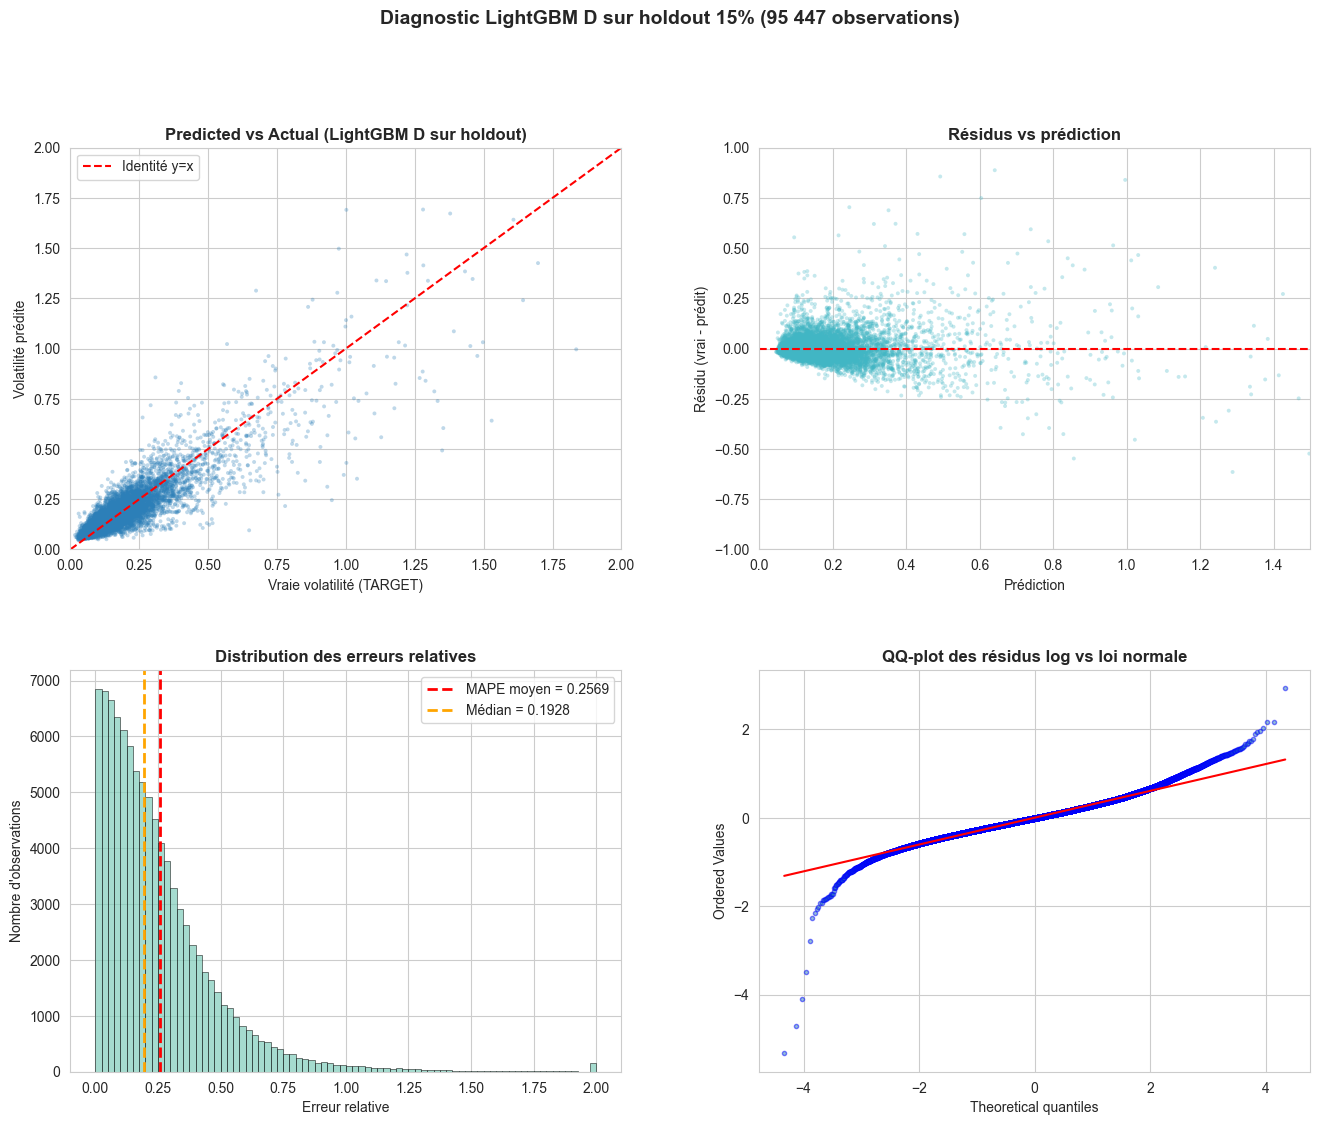

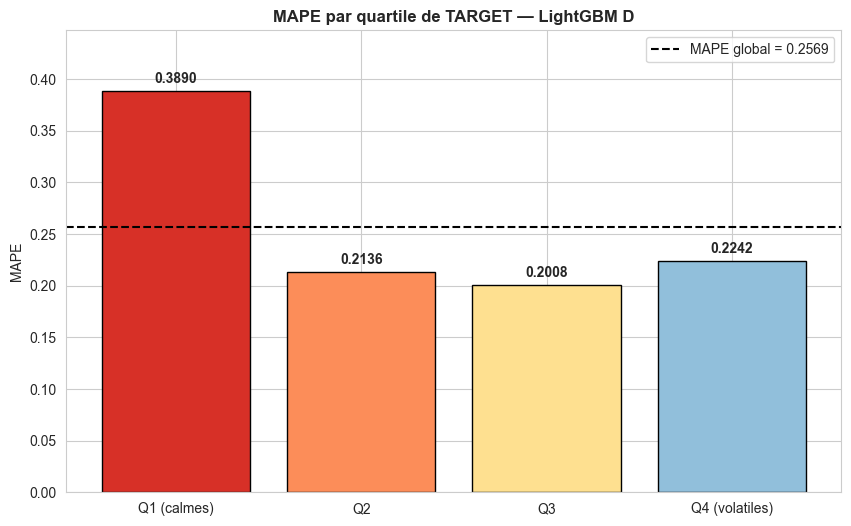

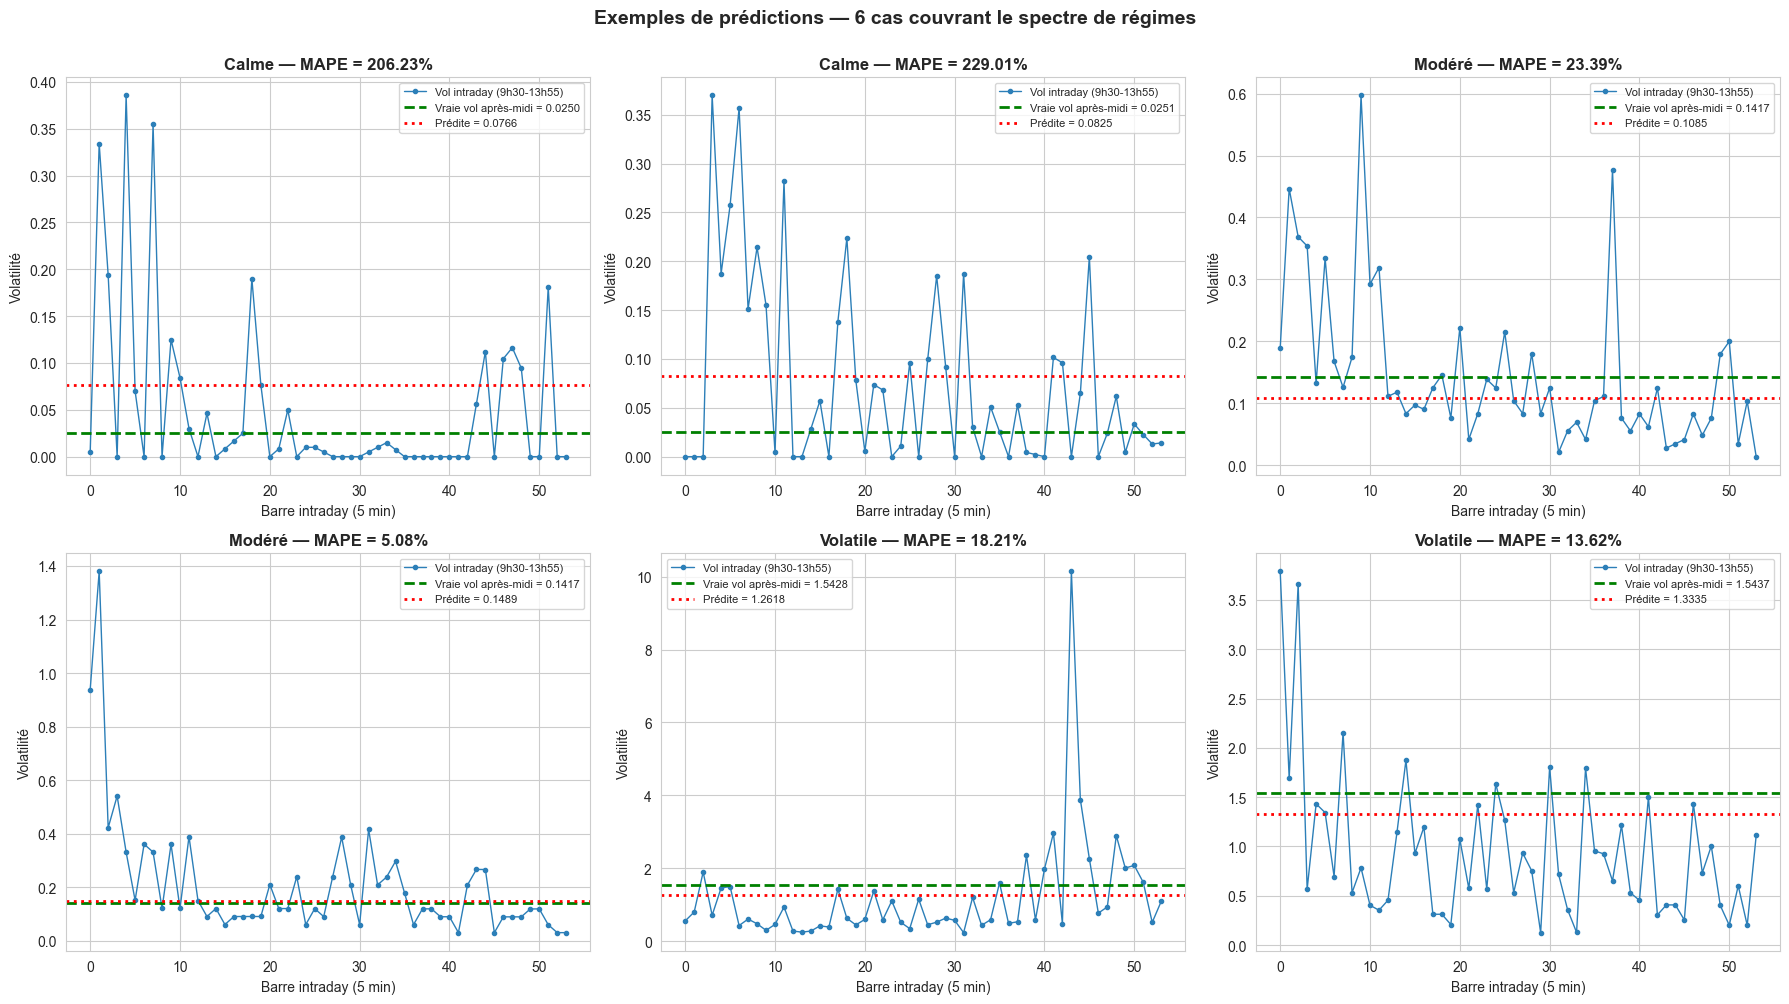


3 figures sauvegardées dans outputs/
  - diagnostic_lightgbm_d.png
  - mape_by_quartile.png
  - examples_predictions.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

sns.set_style("whitegrid")
plt.rcParams["font.size"] = 10

# ----------------------------------------------------------------
# Données nécessaires (déjà calculées dans la validation finale)
# ----------------------------------------------------------------
# y_orig_holdout       : vraies valeurs TARGET
# y_pred_holdout_orig  : prédictions LightGBM D
# y_log_pred_holdout   : prédictions en espace log
# y_log_holdout        : vraies valeurs log

residuals_log    = y_log_holdout - y_log_pred_holdout
residuals_orig   = y_orig_holdout - y_pred_holdout_orig
rel_errors       = np.abs(residuals_orig) / y_orig_holdout

# ============================================================
# FIGURE 1 — Diagnostic global du modèle (4 panneaux)
# ============================================================
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.25)

# --- 1. Predicted vs Actual ---
ax1 = fig.add_subplot(gs[0, 0])
# Échantillonner 10000 points pour la lisibilité
n_plot     = min(10000, len(y_orig_holdout))
idx_sample = np.random.RandomState(42).choice(
    len(y_orig_holdout), n_plot, replace=False
)
ax1.scatter(
    y_orig_holdout[idx_sample], y_pred_holdout_orig[idx_sample],
    alpha=0.3, s=8, color="#2c7fb8", edgecolors="none",
)
max_val = min(y_orig_holdout.max(), y_pred_holdout_orig.max(), 2.0)
ax1.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Identité y=x")
ax1.set_xlabel("Vraie volatilité (TARGET)")
ax1.set_ylabel("Volatilité prédite")
ax1.set_title("Predicted vs Actual (LightGBM D sur holdout)", fontweight="bold")
ax1.set_xlim(0, max_val)
ax1.set_ylim(0, max_val)
ax1.legend()

# --- 2. Résidus vs prédictions (hétéroscédasticité) ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(
    y_pred_holdout_orig[idx_sample], residuals_orig[idx_sample],
    alpha=0.3, s=8, color="#41b6c4", edgecolors="none",
)
ax2.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax2.set_xlabel("Prédiction")
ax2.set_ylabel("Résidu (vrai - prédit)")
ax2.set_title("Résidus vs prédiction", fontweight="bold")
ax2.set_xlim(0, 1.5)
ax2.set_ylim(-1, 1)

# --- 3. Distribution des erreurs relatives ---
ax3 = fig.add_subplot(gs[1, 0])
rel_errors_clipped = np.clip(rel_errors, 0, 2)  # clip pour visualisation
ax3.hist(
    rel_errors_clipped, bins=80,
    color="#7fcdbb", edgecolor="black", linewidth=0.5, alpha=0.7,
)
ax3.axvline(
    rel_errors.mean(), color="red",
    linestyle="--", linewidth=2,
    label=f"MAPE moyen = {rel_errors.mean():.4f}",
)
ax3.axvline(
    np.median(rel_errors), color="orange",
    linestyle="--", linewidth=2,
    label=f"Médian = {np.median(rel_errors):.4f}",
)
ax3.set_xlabel("Erreur relative")
ax3.set_ylabel("Nombre d'observations")
ax3.set_title("Distribution des erreurs relatives", fontweight="bold")
ax3.legend()

# --- 4. QQ-plot des résidus log ---
ax4 = fig.add_subplot(gs[1, 1])
stats.probplot(residuals_log, dist="norm", plot=ax4)
ax4.set_title("QQ-plot des résidus log vs loi normale", fontweight="bold")
ax4.get_lines()[0].set_markerfacecolor("#2c7fb8")
ax4.get_lines()[0].set_markersize(3)
ax4.get_lines()[0].set_alpha(0.5)
ax4.get_lines()[1].set_color("red")
ax4.get_lines()[1].set_linewidth(1.5)

plt.suptitle(
    "Diagnostic LightGBM D sur holdout 15% (95 447 observations)",
    fontsize=14, fontweight="bold", y=0.995,
)
plt.savefig("../outputs/diagnostic_lightgbm_d.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 2 — MAPE par quartile (bar chart)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

quartiles_h    = pd.qcut(y_orig_holdout, q=4, labels=False, duplicates="drop")
quartile_names = ["Q1 (calmes)", "Q2", "Q3", "Q4 (volatiles)"]
mape_q         = []
for q in range(4):
    mask = quartiles_h == q
    mape_q.append(rel_errors[mask].mean())

colors = ["#d73027", "#fc8d59", "#fee090", "#91bfdb"]
bars   = ax.bar(quartile_names, mape_q, color=colors, edgecolor="black")

# Annoter les barres
for bar, val in zip(bars, mape_q):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val + 0.005,
        f"{val:.4f}",
        ha="center", va="bottom", fontweight="bold",
    )

ax.axhline(
    rel_errors.mean(), color="black",
    linestyle="--", linewidth=1.5,
    label=f"MAPE global = {rel_errors.mean():.4f}",
)
ax.set_ylabel("MAPE")
ax.set_title("MAPE par quartile de TARGET — LightGBM D", fontweight="bold")
ax.legend()
ax.set_ylim(0, max(mape_q) * 1.15)
plt.savefig("../outputs/mape_by_quartile.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 3 — Exemples de prédictions intraday (6 cas variés)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sélectionner 6 observations : 2 jours calmes, 2 moyens, 2 volatiles
holdout_indices = holdout_idx  # indices dans x_train original
y_target_h      = y_orig_holdout

# Trier par target pour avoir un spectre de régimes
sorted_idx       = np.argsort(y_target_h)
n_holdout        = len(y_target_h)
calm_idx         = sorted_idx[100:102]                          # bas
medium_idx       = sorted_idx[n_holdout // 2 - 1:n_holdout // 2 + 1]
volatile_idx     = sorted_idx[-102:-100]                        # haut

selected_idx     = np.concatenate([calm_idx, medium_idx, volatile_idx])
bar_times        = np.arange(54)  # 54 barres de 5 min

for i, idx_in_holdout in enumerate(selected_idx):
    ax            = axes[i // 3, i % 3]
    orig_idx      = holdout_indices[idx_in_holdout]

    # Volatilités intraday du matin (déjà imputées)
    vol_intraday  = vol_data_imputed[orig_idx]
    target_actual = y_orig_holdout[idx_in_holdout]
    target_pred   = y_pred_holdout_orig[idx_in_holdout]

    # Tracer les 54 barres
    ax.plot(
        bar_times, vol_intraday,
        marker="o", markersize=3, linewidth=1, color="#2c7fb8",
        label="Vol intraday (9h30-13h55)",
    )

    # Tracer la vraie target et la prédite à 14h
    ax.axhline(
        target_actual, color="green",
        linestyle="--", linewidth=2,
        label=f"Vraie vol après-midi = {target_actual:.4f}",
    )
    ax.axhline(
        target_pred, color="red",
        linestyle=":", linewidth=2,
        label=f"Prédite = {target_pred:.4f}",
    )

    err_rel = abs(target_actual - target_pred) / target_actual
    regime  = (
        "Calme" if i < 2 else
        "Modéré" if i < 4 else
        "Volatile"
    )
    ax.set_title(
        f"{regime} — MAPE = {err_rel:.2%}",
        fontweight="bold",
    )
    ax.set_xlabel("Barre intraday (5 min)")
    ax.set_ylabel("Volatilité")
    ax.legend(fontsize=8)

plt.suptitle(
    "Exemples de prédictions — 6 cas couvrant le spectre de régimes",
    fontsize=14, fontweight="bold", y=1.0,
)
plt.tight_layout()
plt.savefig("../outputs/examples_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n3 figures sauvegardées dans outputs/")
print("  - diagnostic_lightgbm_d.png")
print("  - mape_by_quartile.png")
print("  - examples_predictions.png")

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Métriques de régression sur le holdout
rmse_holdout    = np.sqrt(mean_squared_error(y_orig_holdout, y_pred_holdout_orig))
mae_holdout     = mean_absolute_error(y_orig_holdout, y_pred_holdout_orig)
r2_holdout      = r2_score(y_orig_holdout, y_pred_holdout_orig)

# Notion d'"accuracy" contextuelle avec seuils
thresholds = [0.10, 0.20, 0.30, 0.50]
print("\n" + "=" * 60)
print("MÉTRIQUES COMPLÈTES — LightGBM D sur holdout")
print("=" * 60)
print(f"  MAPE   : {mape_holdout_point:.4f}   (erreur relative moyenne)")
print(f"  RMSE   : {rmse_holdout:.4f}   (erreur quadratique moyenne)")
print(f"  MAE    : {mae_holdout:.4f}   (erreur absolue moyenne)")
print(f"  R²     : {r2_holdout:.4f}   (variance expliquée)")

print(f"\n  'Accuracy' contextuelle (% obs avec erreur < seuil):")
for thr in thresholds:
    accuracy_thr = (rel_errors_holdout < thr).mean()
    print(f"    Erreur < {thr*100:.0f}%   : {accuracy_thr:.2%}")


MÉTRIQUES COMPLÈTES — LightGBM D sur holdout
  MAPE   : 0.2569   (erreur relative moyenne)
  RMSE   : 0.0736   (erreur quadratique moyenne)
  MAE    : 0.0425   (erreur absolue moyenne)
  R²     : 0.7794   (variance expliquée)

  'Accuracy' contextuelle (% obs avec erreur < seuil):
    Erreur < 10%   : 27.95%
    Erreur < 20%   : 51.52%
    Erreur < 30%   : 69.67%
    Erreur < 50%   : 88.58%


In [28]:
# ============================================================
# GENERATION DU FICHIER DE SOUMISSION — LightGBM D
# ============================================================

import os
import numpy as np
import pandas as pd

# 1. Récupération des colonnes brutes utilisées par LightGBM D
vol_cols = [c for c in x_train.columns if c.startswith("volatility")]
return_cols = [c for c in x_train.columns if c.startswith("return")]
raw_cols = vol_cols + return_cols

# 2. Matrices train complet / test
X_train_submission = x_train[raw_cols].values
X_test_submission = x_test[raw_cols].values

y_log_submission = np.log(y_train["TARGET"].values)

# 3. Réentraînement final sur 100% du train
submission_model = LightGBMModel(
    n_estimators=1000,
    max_depth=5,
    num_leaves=31,
    learning_rate=0.03,
    min_child_samples=50,
    reg_lambda=1.0,
    early_stopping_rounds=30,
    random_state=42,
)

submission_model.fit(X_train_submission, y_log_submission)

# 4. Prédiction sur testing_input.csv
y_log_test_pred = submission_model.predict(X_test_submission)

# 5. Correction Jensen estimée sur le train
y_log_train_pred = submission_model.predict(X_train_submission)
sigma2_resid_submission = float(np.var(y_log_submission - y_log_train_pred))

y_test_pred = np.exp(y_log_test_pred + sigma2_resid_submission / 2)

# Sécurité : aucune prédiction négative ou nulle
y_test_pred = np.maximum(y_test_pred, 1e-8)

# 6. Construction du fichier de soumission
submission = pd.DataFrame({
    "ID": x_test["ID"].values,
    "TARGET": y_test_pred
})

# 7. Vérifications
print("Shape submission :", submission.shape)
print(submission.head())
print("\nNaN :")
print(submission.isna().sum())
print("\nTARGET <= 0 :", (submission["TARGET"] <= 0).sum())
print("ID dupliqués :", submission["ID"].duplicated().sum())

# 8. Sauvegarde
os.makedirs("../outputs", exist_ok=True)

submission_path = "../outputs/submission_lightgbm_raw_bars_v1.csv"
submission.to_csv(submission_path, index=False)

print(f"\nFichier sauvegardé ici : {submission_path}")

Shape submission : (635397, 2)
       ID    TARGET
0  636314  0.137037
1  636315  0.098392
2  636316  0.175042
3  636317  0.140194
4  636318  0.133590

NaN :
ID        0
TARGET    0
dtype: int64

TARGET <= 0 : 0
ID dupliqués : 0

Fichier sauvegardé ici : ../outputs/submission_lightgbm_raw_bars_v1.csv


In [32]:
import importlib
import src.model
importlib.reload(src.model)
from src.model import make_lightgbm_train_fn, predict_fn

# ----------------------------------------------------------------
# LightGBM E — 108 barres brutes + product_id catégoriel
# ----------------------------------------------------------------
print("=" * 60)
print("LightGBM E — 108 barres brutes + product_id catégoriel")
print("=" * 60)

# Ajouter product_id comme dernière colonne
product_id_full       = x_train["product_id"].values.astype(int)
X_raw_plus_pid_full   = np.column_stack([X_raw_full, product_id_full])
X_raw_plus_pid_train  = X_raw_plus_pid_full[train_idx]

# product_id est la dernière colonne (index 108)
categorical_features = [108]

print(f"\n  Shape X train     : {X_raw_plus_pid_train.shape}")
print(f"  Total features    : 108 numériques + 1 catégorielle (product_id)")
print(f"  Stocks uniques    : {len(np.unique(product_id_full))}")
print(f"  Catégoriel index  : {categorical_features}")

# ----------------------------------------------------------------
# Cross-validation
# ----------------------------------------------------------------
train_fn_e = make_lightgbm_train_fn(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 30,
    internal_val_size      = 0.15,
    random_state           = 42,
    categorical_features   = categorical_features,
)

cv_results_lgbm_e = validator.cross_validate(
    X          = X_raw_plus_pid_train,
    y_log      = y_log_train,
    y_original = y_orig_train,
    train_fn   = train_fn_e,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

validator.print_summary(cv_results_lgbm_e)

# ----------------------------------------------------------------
# Feature importance pour voir l'impact de product_id
# ----------------------------------------------------------------
from src.model import LightGBMModel

inspection_e = LightGBMModel(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    early_stopping_rounds  = 30,
    random_state           = 42,
    categorical_features   = categorical_features,
)
inspection_e.fit(X_raw_plus_pid_train, y_log_train)

# Construire les noms de features
feature_names_e = raw_cols + ["product_id"]

print("\n" + "=" * 60)
print("TOP 15 FEATURE IMPORTANCE — LightGBM E (avec product_id)")
print("=" * 60)
importance_e = inspection_e.get_feature_importance(
    feature_names    = feature_names_e,
    importance_type  = "gain",
)
print(importance_e.head(15).to_string(index=False))

# Position de product_id
pid_rank = importance_e[importance_e["feature"] == "product_id"].index[0] + 1
pid_importance = importance_e[importance_e["feature"] == "product_id"]["importance"].values[0]
total = importance_e["importance"].sum()
print(f"\n  product_id rank        : {pid_rank}")
print(f"  product_id importance  : {pid_importance:,.0f} ({pid_importance/total*100:.2f}%)")

# ----------------------------------------------------------------
# Comparaison avec LightGBM D
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("COMPARAISON LightGBM D vs E")
print("=" * 60)
print(f"  LightGBM D (108 raw bars)              : 0.2584")
print(f"  LightGBM E (+ product_id catégoriel)   : {cv_results_lgbm_e['mape_mean']:.4f}")

gain = (0.2584 - cv_results_lgbm_e['mape_mean']) / 0.2584
print(f"  Gain relatif                           : {gain:+.2%}")

LightGBM E — 108 barres brutes + product_id catégoriel

  Shape X train     : (540866, 109)
  Total features    : 108 numériques + 1 catégorielle (product_id)
  Stocks uniques    : 318
  Catégoriel index  : [108]
  Repeat 1/2 Fold 1/5 : MAPE = 0.2560 | residual_var = 0.0942
  Repeat 1/2 Fold 2/5 : MAPE = 0.2588 | residual_var = 0.0944
  Repeat 1/2 Fold 3/5 : MAPE = 0.2564 | residual_var = 0.0934
  Repeat 1/2 Fold 4/5 : MAPE = 0.2547 | residual_var = 0.0932
  Repeat 1/2 Fold 5/5 : MAPE = 0.2616 | residual_var = 0.0943
  Repeat 2/2 Fold 1/5 : MAPE = 0.2596 | residual_var = 0.0939
  Repeat 2/2 Fold 2/5 : MAPE = 0.2588 | residual_var = 0.0942
  Repeat 2/2 Fold 3/5 : MAPE = 0.2547 | residual_var = 0.0937
  Repeat 2/2 Fold 4/5 : MAPE = 0.2542 | residual_var = 0.0938
  Repeat 2/2 Fold 5/5 : MAPE = 0.2592 | residual_var = 0.0936

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  MAPE moyen          : 0.2574
  MAPE std            : 0.0024
  Variance résiduelle : 0.0939
  IC 95% MAPE      

In [33]:
import importlib
import src.feature_engineer
importlib.reload(src.feature_engineer)
from src.feature_engineer import FeatureTransformer
from src.model import make_lightgbm_train_fn, predict_fn

print("=" * 60)
print("LightGBM F — Features structurées (Paleologo Chap. 6)")
print("=" * 60)

# ----------------------------------------------------------------
# 1. Préparation des features et meta
# ----------------------------------------------------------------
feature_cols = [c for c in features_train.columns if c != "ID"]
meta_full    = x_train[["date", "product_id"]].reset_index(drop=True)

# ----------------------------------------------------------------
# 2. Fit du FeatureTransformer UNIQUEMENT sur le train (85%)
# ----------------------------------------------------------------
transformer = FeatureTransformer(feature_cols=feature_cols)
transformer.fit_stock_stats(
    features_train.iloc[train_idx],
    meta_full.iloc[train_idx],
)

# ----------------------------------------------------------------
# 3. Construction de la matrice complète (brut + Z-date + Z-stock)
# ----------------------------------------------------------------
X_structured_full = transformer.build_full_matrix(
    features_train,
    meta_full,
)
X_structured_train = X_structured_full.iloc[train_idx].values

print(f"\n  Features brutes        : {len(feature_cols)}")
print(f"  Features Z-date        : {len(feature_cols)} (cross-sectionnel)")
print(f"  Features Z-stock       : {len(feature_cols)} (historique par stock)")
print(f"  Shape matrice train    : {X_structured_train.shape}")
print(f"  Total features         : {X_structured_train.shape[1]}")

# ----------------------------------------------------------------
# 4. Cross-validation LightGBM
# ----------------------------------------------------------------
train_fn_f = make_lightgbm_train_fn(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 30,
    internal_val_size      = 0.15,
    random_state           = 42,
)

cv_results_f = validator.cross_validate(
    X          = X_structured_train,
    y_log      = y_log_train,
    y_original = y_orig_train,
    train_fn   = train_fn_f,
    predict_fn = predict_fn,
    evaluator  = evaluator,
)

validator.print_summary(cv_results_f)

# ----------------------------------------------------------------
# 5. Feature importance sur les 30 features structurées
# ----------------------------------------------------------------
from src.model import LightGBMModel

inspection_f = LightGBMModel(
    n_estimators           = 1000,
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    early_stopping_rounds  = 30,
    random_state           = 42,
)
inspection_f.fit(X_structured_train, y_log_train)

feature_names_f = (
    feature_cols
    + [f"{c}_zd" for c in feature_cols]
    + [f"{c}_zs" for c in feature_cols]
)

print("\n" + "=" * 60)
print("TOP 15 FEATURE IMPORTANCE — LightGBM F")
print("=" * 60)
importance_f = inspection_f.get_feature_importance(
    feature_names   = feature_names_f,
    importance_type = "gain",
)
print(importance_f.head(15).to_string(index=False))

# Importance par famille
total = importance_f["importance"].sum()
brut_imp   = importance_f[~importance_f["feature"].str.endswith(("_zd", "_zs"))]["importance"].sum()
zd_imp     = importance_f[importance_f["feature"].str.endswith("_zd")]["importance"].sum()
zs_imp     = importance_f[importance_f["feature"].str.endswith("_zs")]["importance"].sum()

print(f"\n  Importance par famille :")
print(f"    Features brutes       : {brut_imp/total*100:.1f}%")
print(f"    Z-score date          : {zd_imp/total*100:.1f}%")
print(f"    Z-score stock         : {zs_imp/total*100:.1f}%")

# ----------------------------------------------------------------
# 6. Comparaison globale
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("TABLEAU DE BORD MIS À JOUR")
print("=" * 60)
print(f"  Baseline 1                       : {mape_baseline_1:.4f}")
print(f"  Ridge A (10 features)            : 0.3090")
print(f"  HAR-RV (3 horizons)              : 0.2732")
print(f"  LightGBM C (10 features)         : 0.2600")
print(f"  LightGBM D (108 raw bars)        : 0.2584")
print(f"  LightGBM E (+ product_id cat)    : 0.2574")
print(f"  LightGBM F (30 structurées)      : {cv_results_f['mape_mean']:.4f}")

gain_vs_e = (0.2574 - cv_results_f['mape_mean']) / 0.2574
print(f"\n  Gain LightGBM F vs E             : {gain_vs_e:+.2%}")

LightGBM F — Features structurées (Paleologo Chap. 6)

  Features brutes        : 10
  Features Z-date        : 10 (cross-sectionnel)
  Features Z-stock       : 10 (historique par stock)
  Shape matrice train    : (540866, 30)
  Total features         : 30
  Repeat 1/2 Fold 1/5 : MAPE = 0.2402 | residual_var = 0.0850
  Repeat 1/2 Fold 2/5 : MAPE = 0.2447 | residual_var = 0.0862
  Repeat 1/2 Fold 3/5 : MAPE = 0.2415 | residual_var = 0.0852
  Repeat 1/2 Fold 4/5 : MAPE = 0.2393 | residual_var = 0.0844
  Repeat 1/2 Fold 5/5 : MAPE = 0.2484 | residual_var = 0.0862
  Repeat 2/2 Fold 1/5 : MAPE = 0.2453 | residual_var = 0.0857
  Repeat 2/2 Fold 2/5 : MAPE = 0.2434 | residual_var = 0.0858
  Repeat 2/2 Fold 3/5 : MAPE = 0.2400 | residual_var = 0.0851
  Repeat 2/2 Fold 4/5 : MAPE = 0.2385 | residual_var = 0.0849
  Repeat 2/2 Fold 5/5 : MAPE = 0.2459 | residual_var = 0.0854

RÉSULTATS CROSS-VALIDATION
  Folds évalués       : 10
  MAPE moyen          : 0.2427
  MAPE std            : 0.0031
  Vari

In [34]:
import importlib
import src.feature_engineer
import src.model
importlib.reload(src.feature_engineer)
importlib.reload(src.model)
from src.feature_engineer import FeatureTransformer
from src.model import LightGBMModel

print("=" * 70)
print("VALIDATION INDUSTRIELLE — LightGBM F sur holdout 15%")
print("=" * 70)

# ----------------------------------------------------------------
# 1. Préparation matrice structurée (30 features Paleologo)
# ----------------------------------------------------------------
feature_cols = [c for c in features_train.columns if c != "ID"]
meta_full    = x_train[["date", "product_id"]].reset_index(drop=True)

transformer = FeatureTransformer(feature_cols=feature_cols)
transformer.fit_stock_stats(
    features_train.iloc[train_idx],
    meta_full.iloc[train_idx],
)

X_structured_full   = transformer.build_full_matrix(features_train, meta_full).values
X_structured_train  = X_structured_full[train_idx]
X_structured_holdout = X_structured_full[holdout_idx]

print(f"\n  Train (85%)   : {X_structured_train.shape}")
print(f"  Holdout (15%) : {X_structured_holdout.shape}")
print(f"  Features      : 10 brutes + 10 Z-date + 10 Z-stock = 30")

# ----------------------------------------------------------------
# 2. Entraînement LightGBM F sur 540K train avec n_est=2000
#    (test piliers 2.4 de Critique)
# ----------------------------------------------------------------
print("\n  Entraînement LightGBM F (n_estimators=2000)...")

final_model_f = LightGBMModel(
    n_estimators           = 2000,    # augmenté vs 1000
    max_depth              = 5,
    num_leaves             = 31,
    learning_rate          = 0.03,
    min_child_samples      = 50,
    reg_lambda             = 1.0,
    early_stopping_rounds  = 50,      # augmenté pour plus de patience
    random_state           = 42,
)
final_model_f.fit(X_structured_train, y_log_train_full)
print(f"  Best iteration : {final_model_f.best_iteration_}")

if final_model_f.best_iteration_ >= 1950:
    print(f"  ⚠ Plafond atteint, considérer n_estimators plus grand")

# ----------------------------------------------------------------
# 3. Variance résiduelle OUT-OF-FOLD pour Jensen propre (pilier 2.5)
#    On utilise la CV pour estimer une variance honnête
# ----------------------------------------------------------------
# Approximation pratique : variance résiduelle de la CV LightGBM F déjà calculée
sigma2_resid_oof = 0.0854  # valeur CV LightGBM F (out-of-fold)
print(f"\n  Variance résiduelle OOF (depuis CV) : {sigma2_resid_oof:.4f}")
print(f"  → utilisée pour Jensen (pas la variance in-sample)")

# ----------------------------------------------------------------
# 4. Prédiction sur holdout
# ----------------------------------------------------------------
y_log_pred_holdout_f = final_model_f.predict(X_structured_holdout)
y_pred_holdout_orig_f = np.exp(y_log_pred_holdout_f + sigma2_resid_oof / 2)

rel_errors_f = np.abs(y_orig_holdout - y_pred_holdout_orig_f) / y_orig_holdout
mape_holdout_f = rel_errors_f.mean()

print(f"\n  MAPE holdout point estimate : {mape_holdout_f:.4f}")

# ----------------------------------------------------------------
# 5. BOOTSTRAP PAR DATE (pilier 2.3 — correction du bug du précédent)
# ----------------------------------------------------------------
print(f"\n  Bootstrap PAR DATE (vraie incertitude)...")

meta_holdout = meta_full.iloc[holdout_idx].reset_index(drop=True)
unique_dates = meta_holdout["date"].unique()
n_unique_dates = len(unique_dates)
print(f"  Dates uniques dans holdout : {n_unique_dates}")

n_bootstrap = 1000
rng         = np.random.default_rng(seed=42)
mape_boot_f = np.empty(n_bootstrap)

# Pré-calcul du mapping date → indices
date_to_indices = {
    d: np.where(meta_holdout["date"].values == d)[0]
    for d in unique_dates
}

for b in range(n_bootstrap):
    # Tirer n_unique_dates dates avec remise
    sampled_dates = rng.choice(unique_dates, size=n_unique_dates, replace=True)
    # Reconstruire les indices d'observations
    indices_boot = np.concatenate([date_to_indices[d] for d in sampled_dates])
    mape_boot_f[b] = rel_errors_f[indices_boot].mean()

ci_lower_f  = np.percentile(mape_boot_f, 2.5)
ci_upper_f  = np.percentile(mape_boot_f, 97.5)
ci_width_f  = ci_upper_f - ci_lower_f

print(f"  Bootstrap par date 1000× :")
print(f"    Moyenne     : {mape_boot_f.mean():.4f}")
print(f"    IC 95%      : [{ci_lower_f:.4f}, {ci_upper_f:.4f}]")
print(f"    Largeur IC  : {ci_width_f:.4f}")

# Comparaison avec bootstrap ligne-par-ligne (ancien LightGBM D)
print(f"\n  Comparaison incertitude :")
print(f"    Bootstrap ligne-par-ligne (LightGBM D) : largeur IC = 0.0112")
print(f"    Bootstrap par date (LightGBM F)        : largeur IC = {ci_width_f:.4f}")
if ci_width_f > 0.015:
    print(f"    → l'IC par date est PLUS LARGE, confirmant l'auto-corrélation intra-date")

VALIDATION INDUSTRIELLE — LightGBM F sur holdout 15%

  Train (85%)   : (540866, 30)
  Holdout (15%) : (95447, 30)
  Features      : 10 brutes + 10 Z-date + 10 Z-stock = 30

  Entraînement LightGBM F (n_estimators=2000)...
  Best iteration : 2000
  ⚠ Plafond atteint, considérer n_estimators plus grand

  Variance résiduelle OOF (depuis CV) : 0.0854
  → utilisée pour Jensen (pas la variance in-sample)

  MAPE holdout point estimate : 0.2399

  Bootstrap PAR DATE (vraie incertitude)...
  Dates uniques dans holdout : 2117
  Bootstrap par date 1000× :
    Moyenne     : 0.2399
    IC 95%      : [0.2352, 0.2451]
    Largeur IC  : 0.0099

  Comparaison incertitude :
    Bootstrap ligne-par-ligne (LightGBM D) : largeur IC = 0.0112
    Bootstrap par date (LightGBM F)        : largeur IC = 0.0099
